<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science with Generative AI: Applications to Business</font></center>
<center><font size=6>Robust Data Modeling with Ensembling and Tuning Techniques</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [1]:
# The following libraries are required (versions confirmed already installed locally, matching or exceeding pinned versions)
#!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Train/Test Split Data
from sklearn.model_selection import train_test_split

# Import Classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics and Tuning
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import fbeta_score
from scipy.stats import randint, uniform
from sklearn.metrics import make_scorer

# Oversampling/undersampling tools
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler

# **Loading the dataset**

In [3]:
Data = pd.read_csv('EasyVisa.csv')

In [4]:
df = Data.copy()

# **Overview of the Dataset**

In [5]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
#Get shape of data set
print('The dataframe has ', df.shape[0], 'rows and ', df.shape[1], 'columns.')

The dataframe has  25480 rows and  12 columns.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
#Check for Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [9]:
#Checking there are no duplicated Case IDs - possible error indicator
df['case_id'].is_unique

True

In [10]:
#Check uniqe values in Object columns
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


case_id
['EZYV01' 'EZYV02' 'EZYV03' ... 'EZYV25478' 'EZYV25479' 'EZYV25480']

continent
['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']

education_of_employee
['High School' "Master's" "Bachelor's" 'Doctorate']

has_job_experience
['N' 'Y']

requires_job_training
['N' 'Y']

region_of_employment
['West' 'Northeast' 'South' 'Midwest' 'Island']

unit_of_wage
['Hour' 'Year' 'Week' 'Month']

full_time_position
['Y' 'N']

case_status
['Denied' 'Certified']


In [11]:
#Statistical Summary of Numerical Data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


**Data Overview Observations**

- There are no null values, 9 Object type values, and 2 integer type values, and 1 Float type value
- The data provides wages in various units (per hour, week, month, year). Normalizing this data will prove challenging as we do not know how many hours per week any of these classes or individuals are working.  We can attempt to normalize on a 40 hour work week.  However without the data on hours worked, the classes may prove more informative than the pay amount.  We will attempt to normalize, but keep the unit_of_wage column. (Update: this normalization attempt was tested and ultimately abandoned — see the Wage Normalization writeup below.)
- We have confirmed that there are no duplicated Case IDs or Rows.  Beyond this quick quality check, case_id will not provide us with meaningful data, so we will drop it before further manipulation.
- The minimum number of employees showing -26 clearly indicates and issue with the data.  We will look into this further in univariate EDA below and decide what needs to be done.

In [12]:
#Drop case_id column
df = df.drop('case_id', axis = 1)

#check the drop
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [13]:
#Check most common wage type before converting
df['unit_of_wage'].value_counts(normalize = True)

unit_of_wage
Year     0.901177
Hour     0.084655
Week     0.010675
Month    0.003493
Name: proportion, dtype: float64

In [14]:
#Check full time distribution before converting
df['full_time_position'].value_counts(normalize = True)

full_time_position
Y    0.89376
N    0.10624
Name: proportion, dtype: float64

In [15]:
# Since the vast majority are full time positions paid yearly, 
# we will normalize wages on yearly salary assuming a 40 hour work week, 52 weeks per year.
# Assumptions:
#   Hour  -> Year : hours/week * weeks/year = 40 * 52 = 2,080 working hours/year
#   Week  -> Year : 52 weeks/year
#   Month -> Year : 12 months/year
#   Year  -> Year : no conversion needed

HOURS_PER_YEAR = 40 * 52   # 2,080 — standard full-time annualization factor
WEEKS_PER_YEAR = 52
MONTHS_PER_YEAR = 12

wage_multiplier = {
    "Hour": HOURS_PER_YEAR,
    "Week": WEEKS_PER_YEAR,
    "Month": MONTHS_PER_YEAR,
    "Year": 1
}

# Map each row's unit to its multiplier, then scale prevailing_wage accordingly
df["prevailing_wage_annual"] = df["prevailing_wage"] * df["unit_of_wage"].map(wage_multiplier)

# Confirm the mapping covered every row (no unmapped/NaN units introduced)
assert df["prevailing_wage_annual"].isnull().sum() == 0, "Unmapped unit_of_wage value found."

# Confirm change against old data
df[["prevailing_wage", "unit_of_wage", "prevailing_wage_annual"]].sample(5, random_state=1)

,prevailing_wage,unit_of_wage,prevailing_wage_annual
17639,26842.9100,Year,26842.910
23951,66419.9800,Year,66419.980
8625,887.2921,Hour,1845567.568
20206,49435.8000,Year,49435.800
7471,49865.1900,Year,49865.190


**Observation**
That `$1.8M` stands out as suspicious

In [16]:
# Filter to only rows where unit_of_wage == 'Hour'
hourly = df[df['unit_of_wage'] == 'Hour']

# Summary stats on the prevailing_wage column of that subset
hourly['prevailing_wage'].describe()

count    2157.000000
mean      414.570513
std       275.015000
min         2.136700
25%       152.700300
50%       372.652300
75%       637.311100
max       999.919500
Name: prevailing_wage, dtype: float64

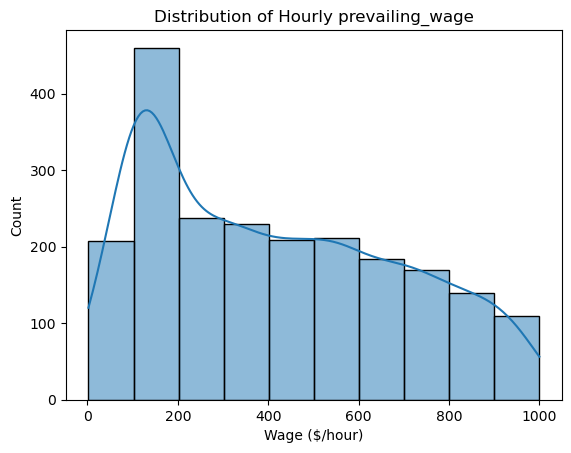

In [17]:
sns.histplot(hourly['prevailing_wage'], bins=10, kde=True)
plt.title('Distribution of Hourly prevailing_wage')
plt.xlabel('Wage ($/hour)')
plt.ylabel('Count')
plt.show()

**Wage Normalization — Investigation and Decision**

- Initial approach: since 90% of records report `prevailing_wage` on a Year basis, we attempted to annualize the remaining Hour/Week/Month records (assuming a 40-hour work week, 2,080 hours/year) into a single comparable `prevailing_wage_annual` feature.
- Issue with the approach: Spot-checking the converted values surfaced implausible results — e.g., an hourly wage of `$887.29` annualized to ~`$1.85M`/year. Investigating further, `prevailing_wage` for all Hour-unit records (2,157 rows, ~8.5% of the dataset) ranges from `$2.14` to `$999.92`/hour with a mean of `$414.57`/hour — far above realistic hourly rates even for high-paid specialty contractors.
- One plausible explanation considered: hourly-rate specialty contractors can legitimately command high hourly rates as compensation for irregular work, no benefits, and gaps between contracts.  However, such work is by its nature irregular and does not lend itself to the 40 hour work week annualization assumption. Additionally, testing this hypothesis against the shape of the data did not support it: a genuine contractor-premium effect should produce a right-skewed distribution (most rates clustered in a realistic band, e.g. `$50-150`/hr, with a thin, shrinking tail of high earners). Instead, the Hour-unit wages are distributed fairly uniformly.

**Decision**: Given this evidence, we will not annualize `prevailing_wage`. Instead, we will retain the raw `prevailing_wage` value as-is and keep `unit_of_wage` as a separate categorical feature, allowing the model to learn any relationship between wage unit and case outcome directly, without forcing a numeric transformation that the underlying data does not support. This decision may be revisited if further analysis in EDA surfaces a stronger justification for a specific treatment of the Hour-unit subset.

In [18]:
#Drop prevailing_wage_annual column
df = df.drop('prevailing_wage_annual', axis = 1)

#View new DataFrame
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


# **Functions Used in EDA**

In [19]:
def plot_distribution(df, column, xlabel='Value', color='steelblue'):
    """
    Plots a horizontal boxplot and histogram with KDE for a given column.
    Adds mean and median lines to the histogram.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to plot
        xlabel  : string, label for the x-axis (default: 'Value')
        color   : string, color for the histogram (default: 'steelblue')
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Horizontal Boxplot
    axes[0].boxplot(df[column].dropna(), vert=False)
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_xlabel(xlabel)

    # Histogram with KDE
    sns.histplot(df[column].dropna(), bins=30, color=color, kde=True, ax=axes[1])

    # Mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[1].legend()
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Frequency')

    plt.suptitle(f'{column} - Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [20]:
def plot_box_count(df, column, xlabel='Value', color='steelblue'):
    """
    Plots a horizontal boxplot and countplot for a given column.
    Adds mean and median lines to the boxplot.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to plot
        xlabel  : string, label for the x-axis (default: 'Value')
        color   : string, color for the histogram (default: 'steelblue')
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Horizontal Boxplot
    axes[0].boxplot(df[column].dropna(), vert=False)
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_xlabel(xlabel)

    # Countplot
    sns.countplot(data=df, x=column, color=color, ax=axes[1])

    # Mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[1].legend()
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Frequency')

    plt.suptitle(f'{column} - Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [21]:
def describe_distribution(df, column):
    """
    Prints IQR-based outlier fences, outlier count, skewness interpretation,
    and descriptive statistics for a given column.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to analyze
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
    print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
    outliers = df[(df[column] < Q1 - 1.5*IQR) |
                  (df[column] > Q3 + 1.5*IQR)]
    print(f"Outlier count: {len(outliers)}")

    print('Skewness: ', df[column].skew())
    if df[column].skew() < -1:
        print('The distribution is highly skewed to the left.')
    elif df[column].skew() > 1:
        print('The distribution is highly skewed to the right.')
    elif df[column].skew() > 0.5:
        print('The distribution is moderately skewed to the right.')
    elif df[column].skew() < -0.5:
        print('The distribution is moderately skewed to the left.')
    else:
        print('The distribution is approximately symmetric.')

    display(df[column].describe())

In [22]:
def find_correlations(df, threshold):
    """
    Returns pairs of numeric variables whose absolute correlation
    exceeds the specified threshold.

    Parameters:
        df (DataFrame): Input dataframe
        threshold (float): Minimum absolute correlation to return

    Returns:
        Series of correlation pairs sorted by absolute correlation
    """
    
    corr = df.select_dtypes(include='number').corr()
    #Upper triangle mask to hide duplicates
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    strong_corr = (
        corr.where(mask)
            .stack()
            .loc[lambda x: abs(x) > threshold]
            .sort_values(key=abs, ascending=False)
    )

    return strong_corr

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

**Leading Questions** (Assigned as part of coursework)

1. What is the distribution of visa case statuses (certified vs. denied)? 66.8% approved; 33.2% Denied
2. How does the education level of employees impact visa approval rates? Yes, Doctorate's have the highest approval rate at 87.2% while High School Education has the lowest at 34.0%
3. Is there a significant difference in visa approval rates between employees with and without prior job experience? Case status appears to be heavily influenced by job experience with a 74.5% approval rate for those with experience vs a 56.1% approval rate for those without.
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval? The distribution of wages for both approvals and denials look very comparable across wage types.
5. Do certain regions in the US have higher visa approval rates compared to others? Yes, Midwest region has the highest percent of cases approved (75.5%) while Island region has the lowest percent approved (60.3%)
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate? Certified and denied applications have extremely similar distributions across company sizes.
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates? Europe has the highest proportion of applications approved (79.2%) while South America has the lowest (57.9%)

## Univariate EDA

### Employee Continent

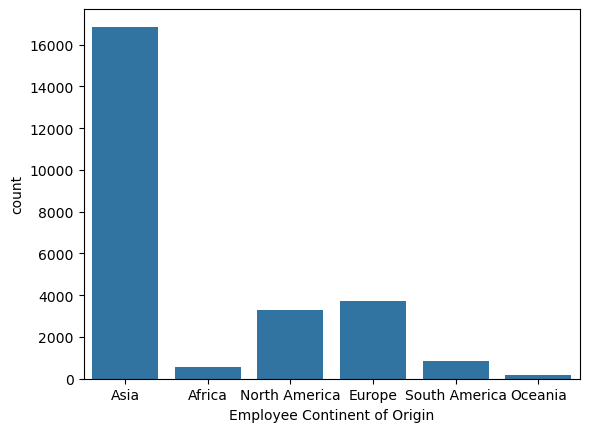

In [23]:
#Count of Applicants by Continent of Origin Visualized
sns.countplot(
    data=df,
    x='continent',
)
plt.xlabel('Employee Continent of Origin')
plt.show()

In [24]:
#Applicants by Continent of Origin Normalized
df['continent'].value_counts(normalize = True)

continent
Asia             0.661735
Europe           0.146468
North America    0.129199
South America    0.033438
Africa           0.021625
Oceania          0.007535
Name: proportion, dtype: float64

**Continent Observations**
- 66.2% of applicants in the dataset are from Asia with the next highest continent being Europe at 14.6%

### Employee Education

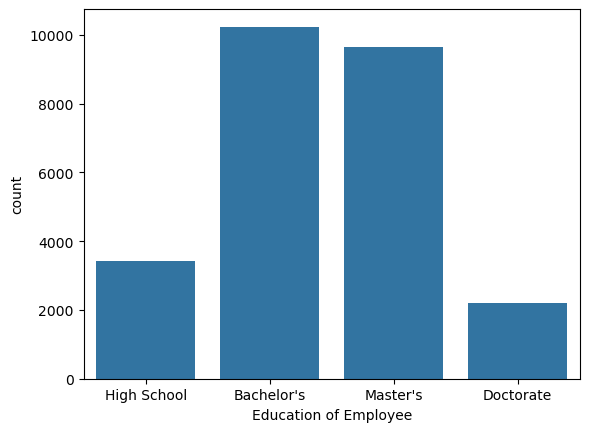

In [25]:
# Count of Applicant Education Levels Visualized
education_order= [
    "High School",
    "Bachelor's",
    "Master's",
    "Doctorate"
    ]

sns.countplot(
    data=df,
    x='education_of_employee',
    order=education_order
)
plt.xlabel('Education of Employee')
plt.show()

In [26]:
#Applicant Education Levels Normalized
df['education_of_employee'].value_counts(normalize = True)

education_of_employee
Bachelor's     0.401648
Master's       0.378100
High School    0.134223
Doctorate      0.086028
Name: proportion, dtype: float64

**Education Observations**
- Applicant education is concentrated in the Bachelor's (40%) and Master's (38%) degrees

### Job Experience

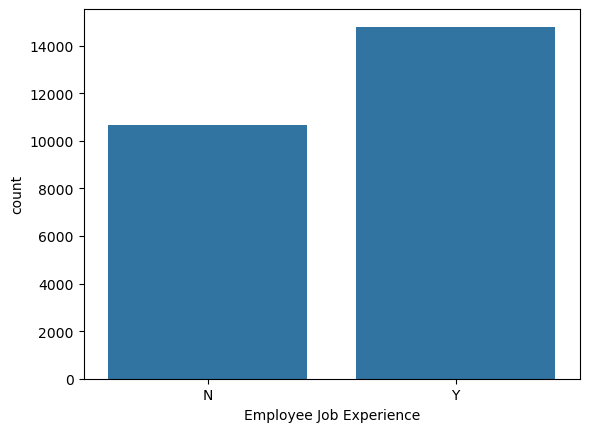

In [27]:
sns.countplot(
    data=df,
    x='has_job_experience',
)
plt.xlabel('Employee Job Experience')
plt.show()

In [28]:
#Applicant Job Experience Normalized
df['has_job_experience'].value_counts(normalize = True)

has_job_experience
Y    0.580926
N    0.419074
Name: proportion, dtype: float64

**Experience Observations**
- 58% of applicants have job experience while 42% do not

### Employee Requires Training

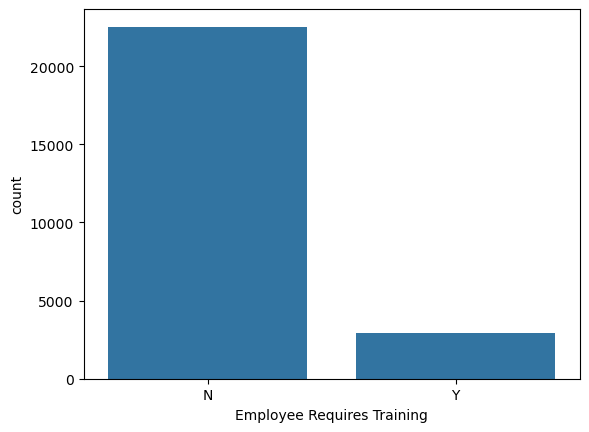

In [29]:
#Count of Employees who require training
sns.countplot(
    data=df,
    x='requires_job_training',
)
plt.xlabel('Employee Requires Training')
plt.show()

In [30]:
#Applicants who require Training Normalized
df['requires_job_training'].value_counts(normalize = True)

requires_job_training
N    0.884027
Y    0.115973
Name: proportion, dtype: float64

**Training Observations**
- 11.6% of applications require the applicant to be trained

### Number of Employees in Company

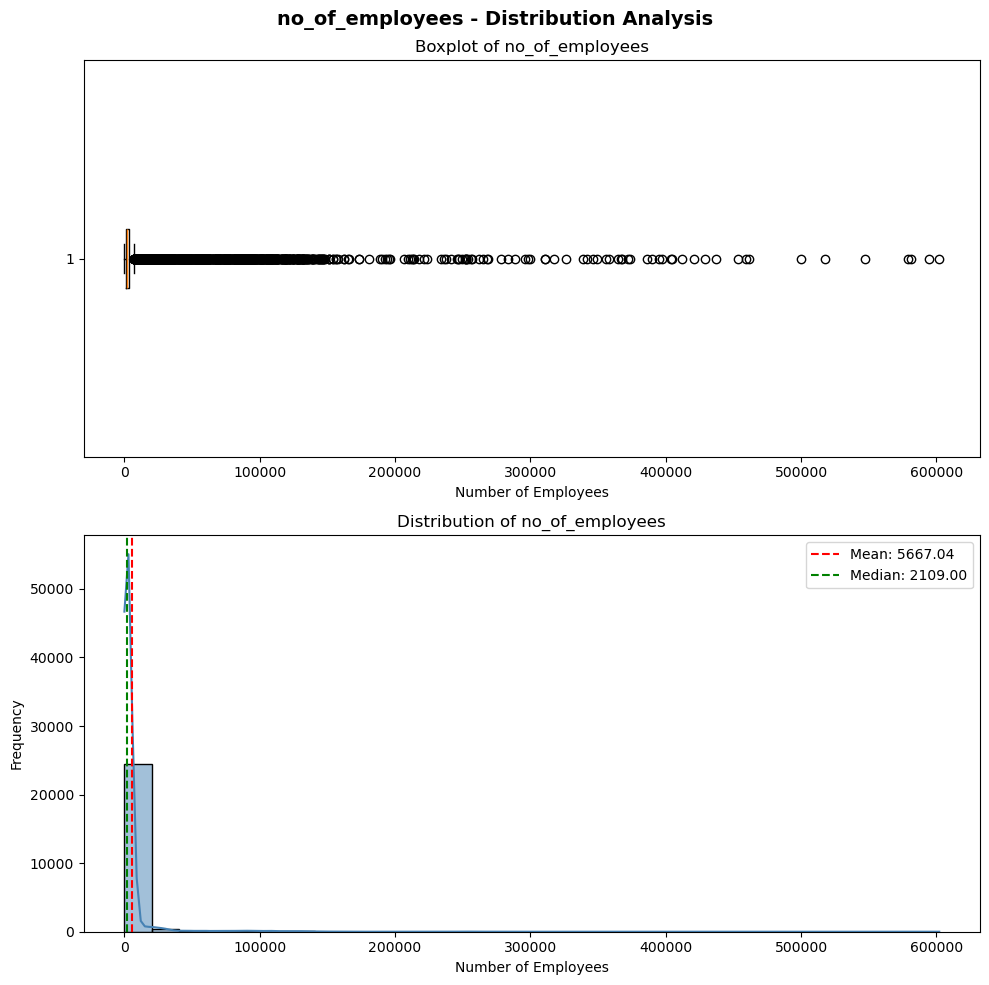

In [31]:
#Distribution of Employee Count per company
plot_distribution(df, 'no_of_employees', xlabel='Number of Employees')

In [32]:
describe_distribution(df, 'no_of_employees')

Lower Outlier Fence = -2701.0
Upper Outlier Fence = 7227.0
Outlier count: 1556
Skewness:  12.265260077708275
The distribution is highly skewed to the right.


count     25480.000000
mean       5667.043210
std       22877.928848
min         -26.000000
25%        1022.000000
50%        2109.000000
75%        3504.000000
max      602069.000000
Name: no_of_employees, dtype: float64

**Number Of Employee Observations**
- Employee headcounts at the companies on the Visa applications range from -26 to 602,069 in this dataset.
- Outliers to the right represent legitimate data and will not be treated.  Companies of >600,000 employees do exist in small numbers and the distribution of company size appears reasonable.
- We need to further investigate the negative headcounts

In [33]:
#Get count of entries with negative or 0 employees
(df['no_of_employees'] <= 0).sum()

np.int64(33)

In [34]:
#Display rows with negative employees to futher inspect
df[df['no_of_employees'] < 0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In Line Observation: There are no obvious commonalities, but these appear to be reasonable employee counts for small companies and start ups.  Let's investigate further.

In [35]:
# Find Percent of data represented by these negative values
print('Percent of data showing negative employee headcount: ', 
      round((df['no_of_employees'] < 0).mean() * 100, 2),
      '%'
     )

Percent of data showing negative employee headcount:  0.13 %


In [36]:
# Distribution of just the negative rows
describe_distribution(df[df['no_of_employees'] < 0], 'no_of_employees')

Lower Outlier Fence = -46.0
Upper Outlier Fence = 10.0
Outlier count: 0
Skewness:  -0.3504917181165756
The distribution is approximately symmetric.


count    33.000000
mean    -17.757576
std       6.285053
min     -26.000000
25%     -25.000000
50%     -14.000000
75%     -11.000000
max     -11.000000
Name: no_of_employees, dtype: float64

In [37]:
# Distribution of just the positive rows
describe_distribution(df[df['no_of_employees'] >= 0], 'no_of_employees')

Lower Outlier Fence = -2697.25
Upper Outlier Fence = 7228.75
Outlier count: 1556
Skewness:  12.257841915422253
The distribution is highly skewed to the right.


count     25447.000000
mean       5674.415334
std       22891.842245
min          12.000000
25%        1025.000000
50%        2112.000000
75%        3506.500000
max      602069.000000
Name: no_of_employees, dtype: float64

**Negative Employee Count Handling Decision**

Decision: We will treat these as sign corrupted and flip their sign to positive.

Rationale: 33 rows (0.13% of data) have negative employee counts, which is not physically meaningful. Comparing the flipped magnitudes (11-26) against the dataset's legitimate minimum (12) shows these values land naturally at the low end of the real distribution, consistent with small companies whose sign was corrupted during data entry/parsing, rather than being missing or nonsensical. We correct via absolute value rather than imputing, to preserve this recoverable information instead of discarding it.

In [38]:
# Correct sign-flip data entry errors in no_of_employees.
df['no_of_employees'] = df['no_of_employees'].abs()

# Confirm no negative values remain
assert (df['no_of_employees'] < 0).sum() == 0, "Negative values still present."

### Year of Establishment

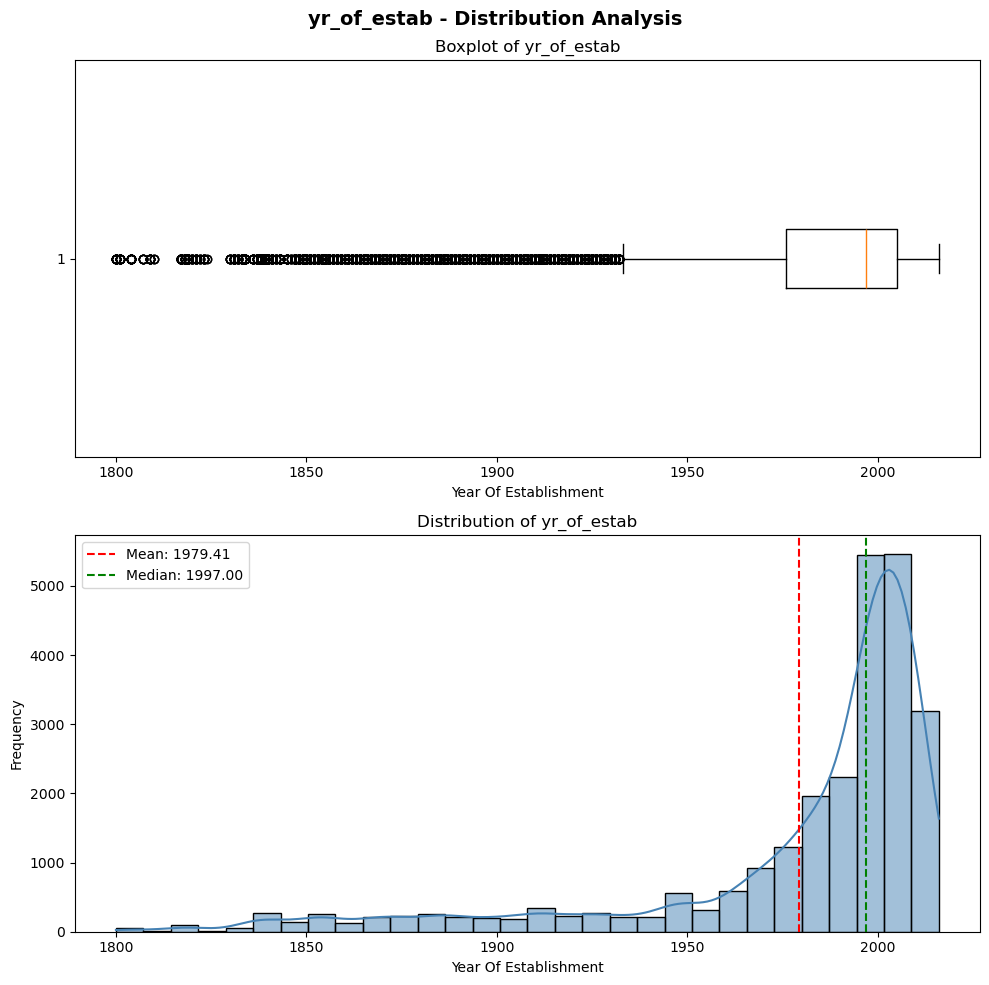

In [39]:
#Companies by year they were established
plot_distribution(df, 'yr_of_estab', xlabel='Year Of Establishment', color='steelblue')

**Feature Engineering Note:**
It is fair to assess that company age is more meaningful than year of establishment and more useful as time goes on, so we will transform yr_of_estab to company_age here.

In [40]:
# Transform yr_of_estab to company_age
# Reference year is 2016 (the case study is grounded in 2016 data,
# not the current calendar year — using today's date would make company_age
# drift every time this notebook is rerun in the
# future, and would misrepresent age at the time these applications were filed.

REFERENCE_YEAR = 2016

df['company_age'] = REFERENCE_YEAR - df['yr_of_estab']

# Check no ages less than 0
assert (df['company_age'] < 0).sum() == 0, "Found company_age < 0 — check yr_of_estab for future-dated values."

df[['yr_of_estab', 'company_age']].sample(5, random_state=1)

,yr_of_estab,company_age
17639,1992,24
23951,1938,78
8625,2005,11
20206,1986,30
7471,1928,88


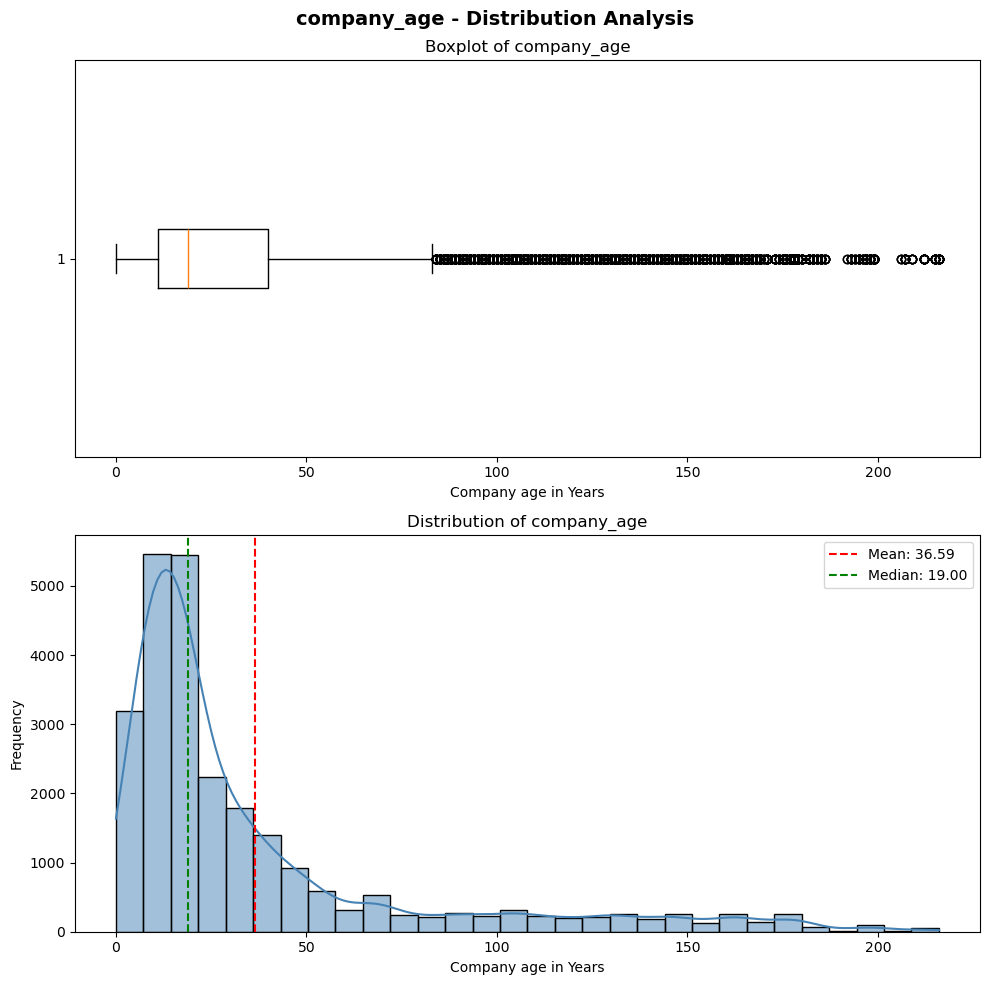

In [41]:
#Companies by age (years since establishment)
plot_distribution(df, 'company_age', xlabel='Company age in Years', color='steelblue')

In [42]:
describe_distribution(df, 'company_age')

Lower Outlier Fence = -32.5
Upper Outlier Fence = 83.5
Outlier count: 3260
Skewness:  2.037301271676439
The distribution is highly skewed to the right.


count    25480.000000
mean        36.590071
std         42.366929
min          0.000000
25%         11.000000
50%         19.000000
75%         40.000000
max        216.000000
Name: company_age, dtype: float64

**Year of Establishment and Age Observations**
- Companies range from being established in 1800 to 2016.
- While there are many outliers, they represent legitimate data and will not be treated.  Companies dating back to 1800 are not unheard of and these older companies represent a realistic amount and distribution of the data.
- 75% of Companies were established within the 40 years prior to 2016 when this data was collected.

### Intended Region of Employment

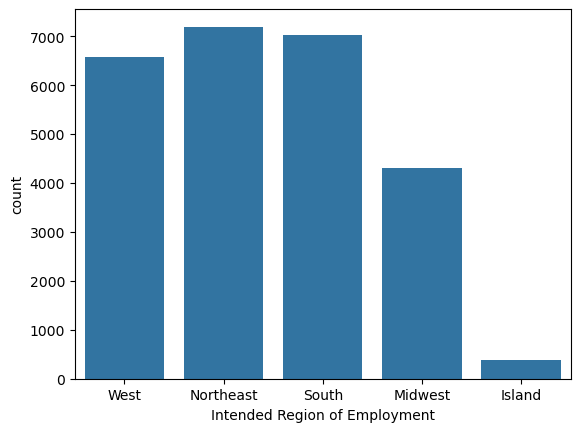

In [43]:
#Count of applications by intended region of employment
sns.countplot(
    data=df,
    x='region_of_employment',
)
plt.xlabel('Intended Region of Employment')
plt.show()

In [44]:
#Applications by intended region of employment normalized
df['region_of_employment'].value_counts(normalize = True)

region_of_employment
Northeast    0.282378
South        0.275392
West         0.258477
Midwest      0.169035
Island       0.014717
Name: proportion, dtype: float64

**Intended Region of Employment Observations**
- Island and Midwest trail the other regions in applications.

### Prevailing Wage

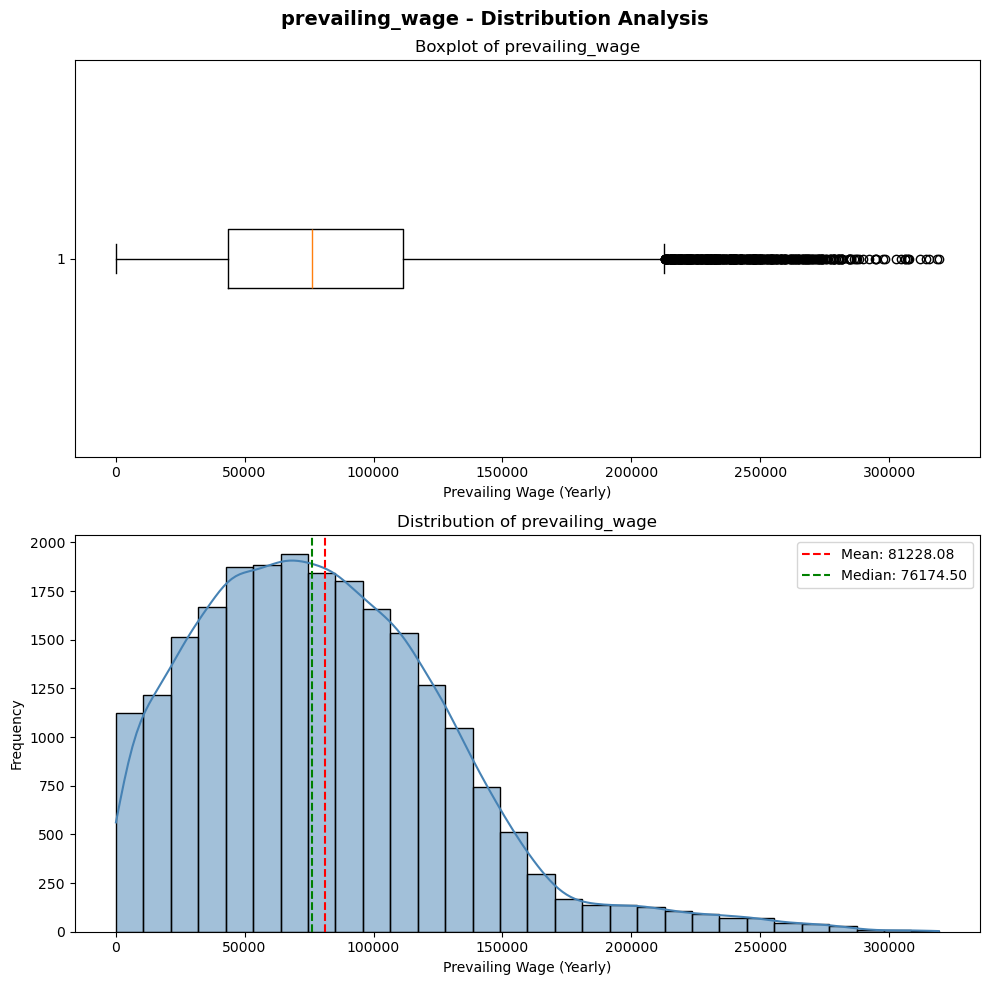

In [45]:
#Prevailing Wage for Yearly Wages
plot_distribution(
    df[df['unit_of_wage'] == 'Year'],
    'prevailing_wage',
    xlabel='Prevailing Wage (Yearly)',
    color='steelblue'
)

In [46]:
describe_distribution(df[df['unit_of_wage'] == 'Year'], 'prevailing_wage')

Lower Outlier Fence = -57723.052499999976
Upper Outlier Fence = 212780.96749999997
Outlier count: 473
Skewness:  0.8655694846937119
The distribution is moderately skewed to the right.


count     22962.000000
mean      81228.077133
std       49951.473223
min         100.000000
25%       43715.955000
50%       76174.500000
75%      111341.960000
max      319210.270000
Name: prevailing_wage, dtype: float64

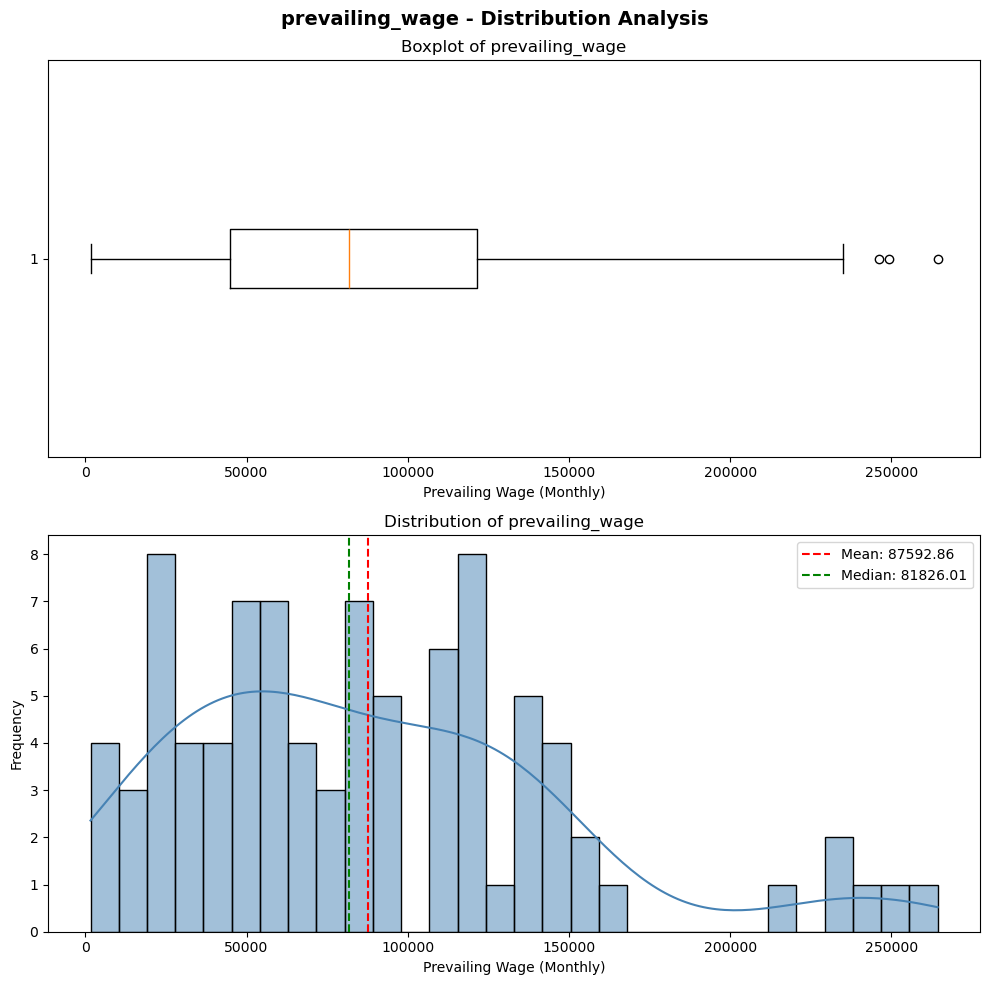

In [47]:
#Prevailing Wage for Monthly Wages
plot_distribution(
    df[df['unit_of_wage'] == 'Month'],
    'prevailing_wage',
    xlabel='Prevailing Wage (Monthly)',
    color='steelblue'
)

In [48]:
describe_distribution(df[df['unit_of_wage'] == 'Month'], 'prevailing_wage')

Lower Outlier Fence = -69978.80000000002
Upper Outlier Fence = 236594.64
Outlier count: 3
Skewness:  0.9638152264168949
The distribution is moderately skewed to the right.


count        89.000000
mean      87592.864045
std       59525.124924
min        1599.280000
25%       44986.240000
50%       81826.010000
75%      121629.600000
max      264362.950000
Name: prevailing_wage, dtype: float64

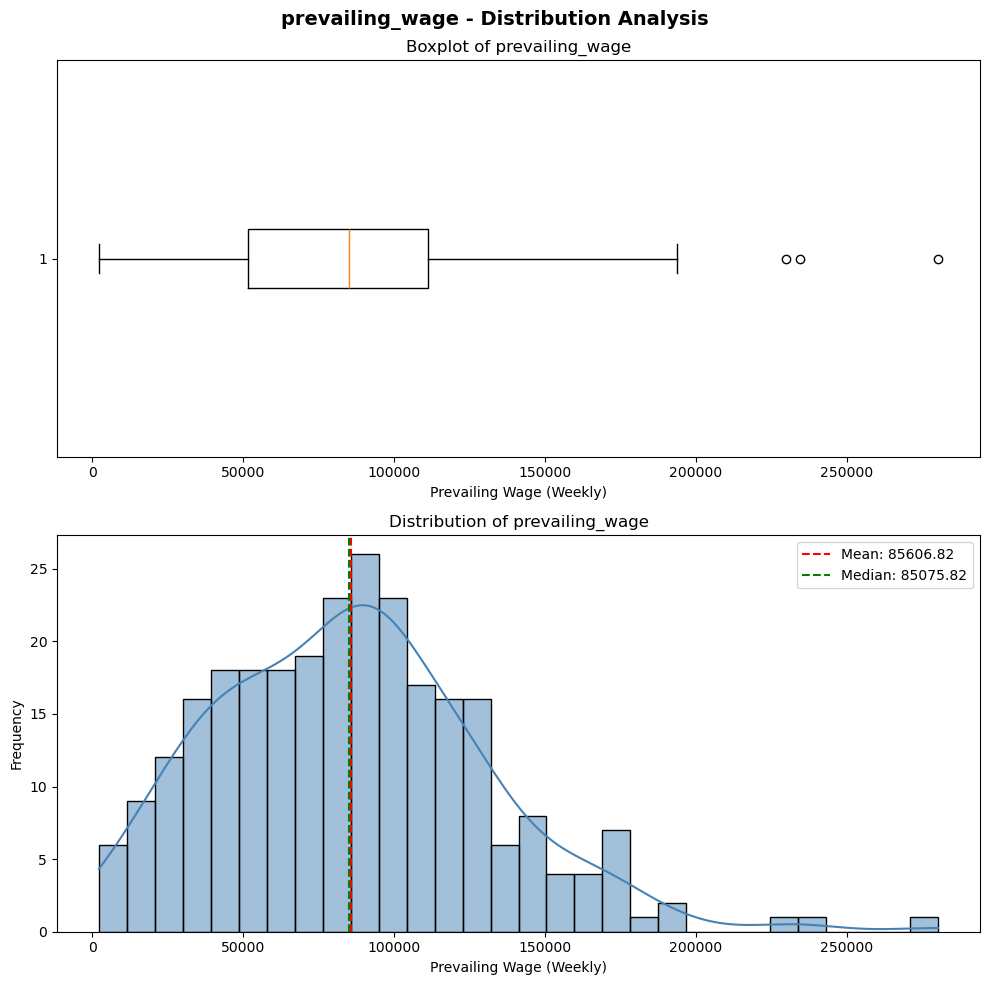

In [49]:
#Prevailing Wage for Weekly Wages
plot_distribution(
    df[df['unit_of_wage'] == 'Week'],
    'prevailing_wage',
    xlabel='Prevailing Wage (Weekly)',
    color='steelblue'
)

In [50]:
describe_distribution(df[df['unit_of_wage'] == 'Week'], 'prevailing_wage')

Lower Outlier Fence = -38477.171250000014
Upper Outlier Fence = 201217.35875
Outlier count: 3
Skewness:  0.6577113245551544
The distribution is moderately skewed to the right.


count       272.000000
mean      85606.820515
std       44802.704810
min        2183.230000
25%       51408.277500
50%       85075.820000
75%      111331.910000
max      280175.950000
Name: prevailing_wage, dtype: float64

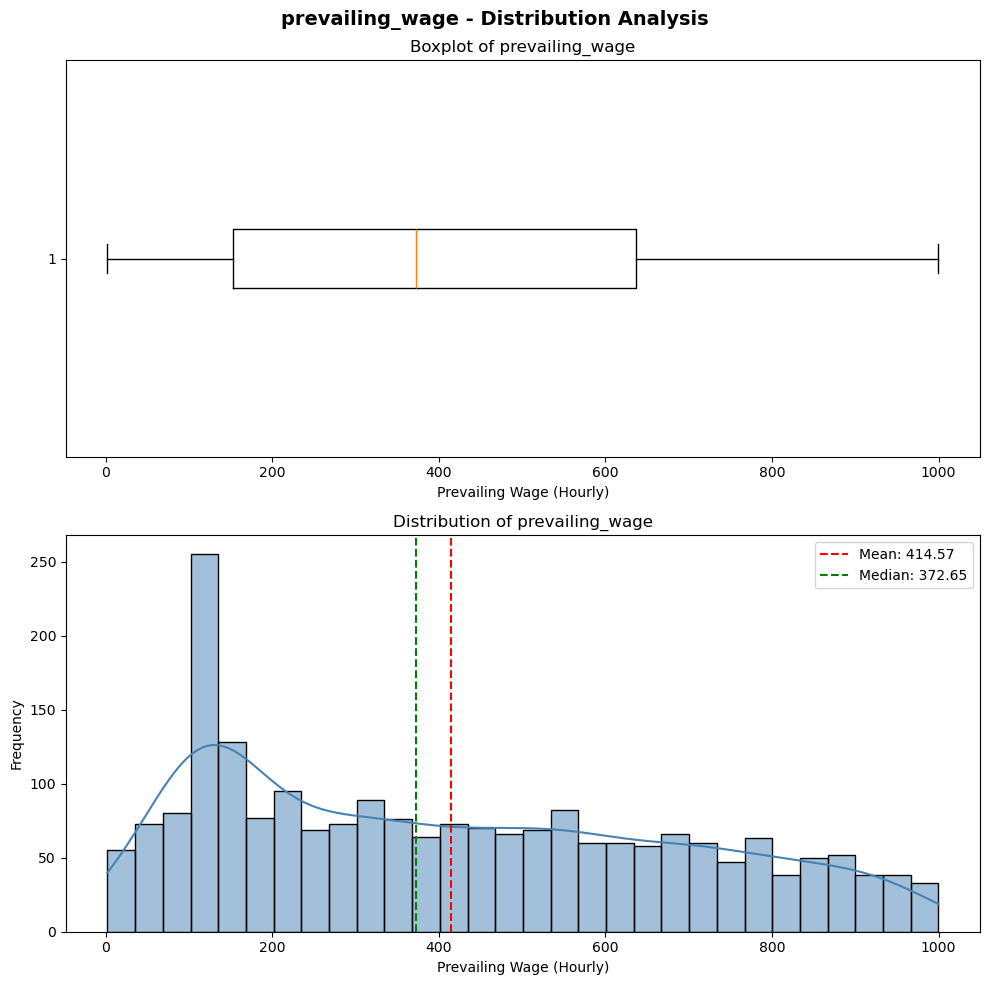

In [51]:
#Prevailing Wage for Hourly Wages
plot_distribution(
    df[df['unit_of_wage'] == 'Hour'],
    'prevailing_wage',
    xlabel='Prevailing Wage (Hourly)',
    color='steelblue'
)

In [52]:
describe_distribution(df[df['unit_of_wage'] == 'Hour'], 'prevailing_wage')

Lower Outlier Fence = -574.2159000000001
Upper Outlier Fence = 1364.2273
Outlier count: 0
Skewness:  0.38972972221612573
The distribution is approximately symmetric.


count    2157.000000
mean      414.570513
std       275.015000
min         2.136700
25%       152.700300
50%       372.652300
75%       637.311100
max       999.919500
Name: prevailing_wage, dtype: float64

**Wage Observations**
- Wages tend to skew moderately right.
- Each wage type has outliers to the right except Hourly.  While some of these outliers seem unlikely (ie `$280,176` weekly salary), they will not be trimmed as this is classroom data, represents a significant portion of the data (ie 25% > `$111,331` weekly), and was likely introduced to engineer some outcome.  Real world outliers in this great a number would call into question the integrity of the data set.
- On the low end the $100 per year wage seems impossibly low.  We dive deeper into this and make a decision in the multivariate section below.

### Unit of Wage

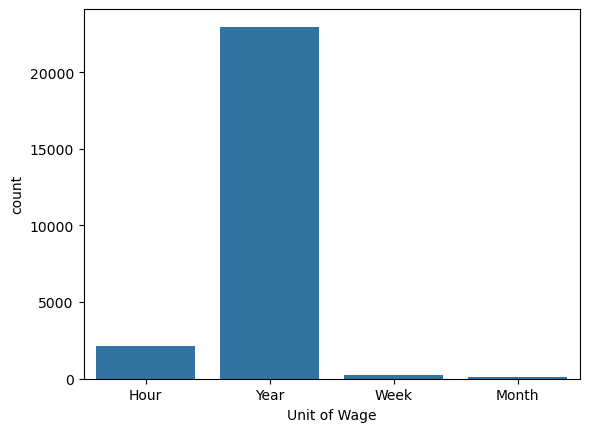

In [53]:
#Count of applications by unit of wage
sns.countplot(
    data=df,
    x='unit_of_wage',
)
plt.xlabel('Unit of Wage')
plt.show()

In [54]:
#Applications by unit of wage
df['unit_of_wage'].value_counts(normalize = True)

unit_of_wage
Year     0.901177
Hour     0.084655
Week     0.010675
Month    0.003493
Name: proportion, dtype: float64

**Unit of Wage Observations**
- 90% of applicants have a yearly unit of wage

### Full Time Status

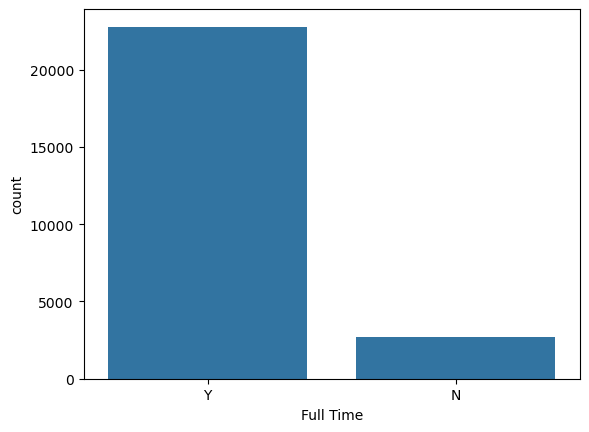

In [55]:
#Count of applications by full time status
sns.countplot(
    data=df,
    x='full_time_position',
)
plt.xlabel('Full Time')
plt.show()

In [56]:
#Applications by full time status
df['full_time_position'].value_counts(normalize = True)

full_time_position
Y    0.89376
N    0.10624
Name: proportion, dtype: float64

**Full Time Status Observations**
- 89.3% of applications are for full time positions

### Case Status

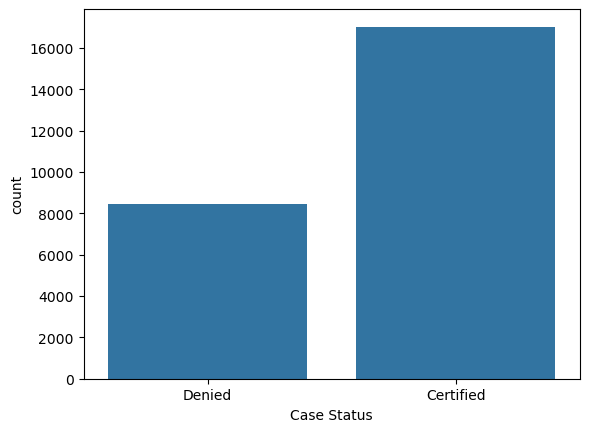

In [57]:
#Count of approvals and denials
sns.countplot(
    data=df,
    x='case_status',
)
plt.xlabel('Case Status')
plt.show()

In [58]:
#Application approvals and denials
df['case_status'].value_counts(normalize = True)

case_status
Certified    0.667896
Denied       0.332104
Name: proportion, dtype: float64

**Case Status Observations**
- 66.8% of Applications for visa were approved and certified. **(Leading Question 1)**

## Multivariate Analysis

### Heatmap

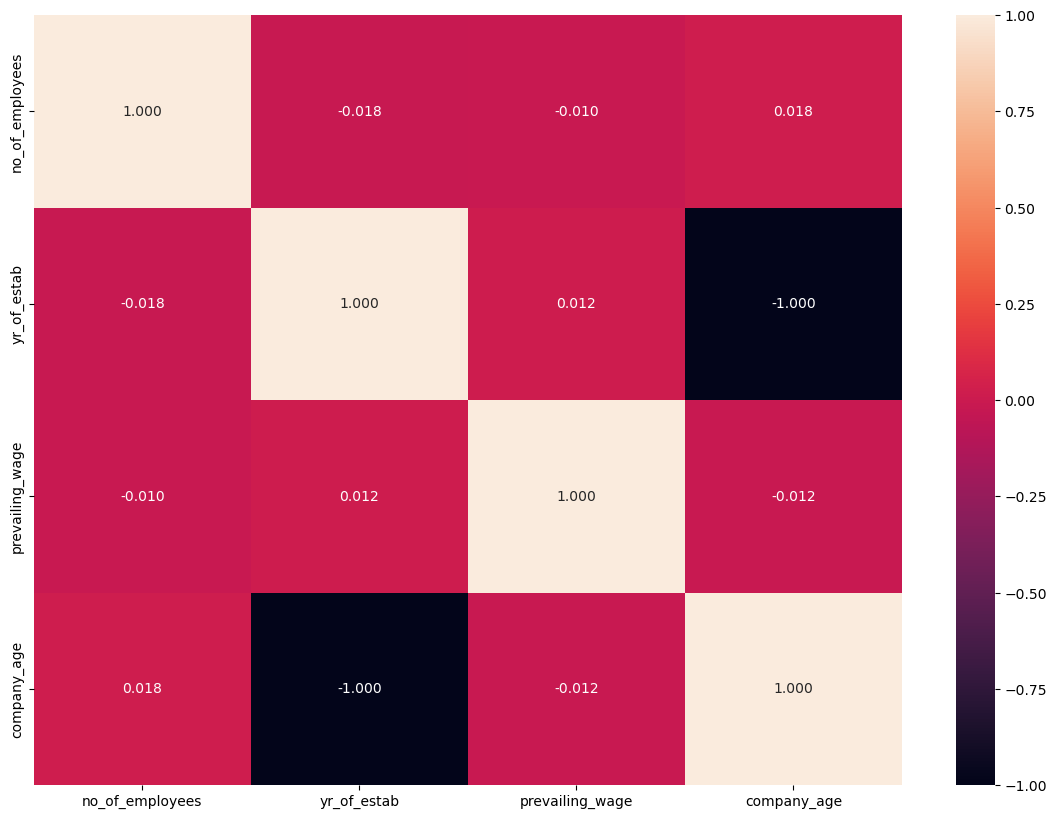

In [59]:
# Heatmap of numeric values
plt.figure(figsize=(14, 10))
sns.heatmap(
    data = df.select_dtypes(include='number').corr(), 
    annot=True,
    fmt='.3f'
)
plt.show()

**Heatmap Observations**
- No strong correlations (except the linear relationship from transferring yr_of_establishment to company-age

### Continent Multivariate

#### Continent v Education of Employee

In [60]:
#Continent vs. Education
pd.crosstab(
    df['continent'],
    df['education_of_employee'],
    normalize='index'
)

education_of_employee,Bachelor's,Doctorate,High School,Master's
continent,,,,
Africa,0.259528,0.098004,0.119782,0.522686
Asia,0.425123,0.054742,0.135816,0.384319
Europe,0.348071,0.226688,0.131297,0.293944
North America,0.372114,0.078372,0.121810,0.427704
Oceania,0.343750,0.114583,0.187500,0.354167
South America,0.390845,0.104460,0.160798,0.343897


#### Continent v Job Experience

In [61]:
#Continent vs. Job Experience
pd.crosstab(
    df['continent'],
    df['has_job_experience'],
    normalize='index'
)

has_job_experience,N,Y
continent,,
Africa,0.393829,0.606171
Asia,0.419370,0.580630
Europe,0.422294,0.577706
North America,0.409478,0.590522
Oceania,0.463542,0.536458
South America,0.442488,0.557512


#### Continent v Training Needed

In [62]:
#Continent vs. Job Experience
pd.crosstab(
    df['continent'],
    df['requires_job_training'],
    normalize='index'
)

requires_job_training,N,Y
continent,,
Africa,0.925590,0.074410
Asia,0.896329,0.103671
Europe,0.801983,0.198017
North America,0.924666,0.075334
Oceania,0.848958,0.151042
South America,0.823944,0.176056


#### Continent v Destination Region of Employment

In [63]:
#Continent vs. Region of Employment
pd.crosstab(
    df['continent'],
    df['region_of_employment'],
    normalize='index'
)

region_of_employment,Island,Midwest,Northeast,South,West
continent,,,,,
Africa,0.014519,0.166969,0.384755,0.185118,0.248639
Asia,0.013404,0.199929,0.272167,0.284977,0.229524
Europe,0.008574,0.081190,0.258574,0.260718,0.390943
North America,0.024909,0.119077,0.338396,0.264277,0.253341
Oceania,0.020833,0.197917,0.255208,0.229167,0.296875
South America,0.026995,0.130282,0.312207,0.261737,0.268779


#### Continent v Wage Type

In [64]:
#Continent vs. Wage Type
pd.crosstab(
    df['continent'],
    df['unit_of_wage'],
    normalize='index'
)

unit_of_wage,Hour,Month,Week,Year
continent,,,,
Africa,0.065336,0.005445,0.014519,0.914701
Asia,0.077753,0.003440,0.009134,0.909673
Europe,0.037513,0.001876,0.004555,0.956056
North America,0.150365,0.005164,0.022783,0.821689
Oceania,0.093750,0.010417,0.020833,0.875000
South America,0.184272,0.002347,0.016432,0.796948


#### Continent v Wage Amount (by wage type)

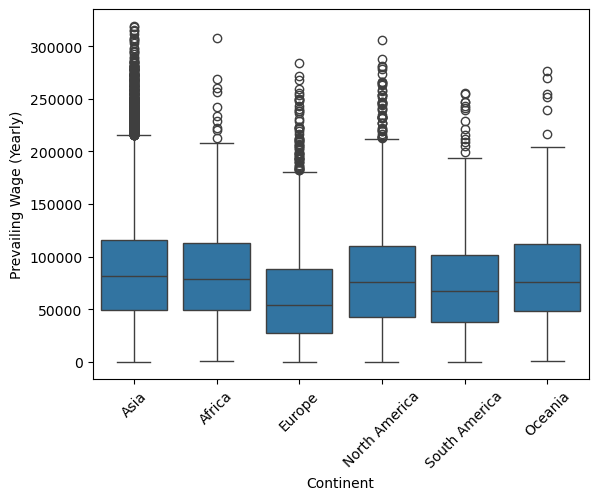

In [65]:
# Continent v Yearly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Year'],
    x='continent',
    y='prevailing_wage'
)
plt.xlabel('Continent')
plt.ylabel('Prevailing Wage (Yearly)')
plt.xticks(rotation=45)
plt.show()

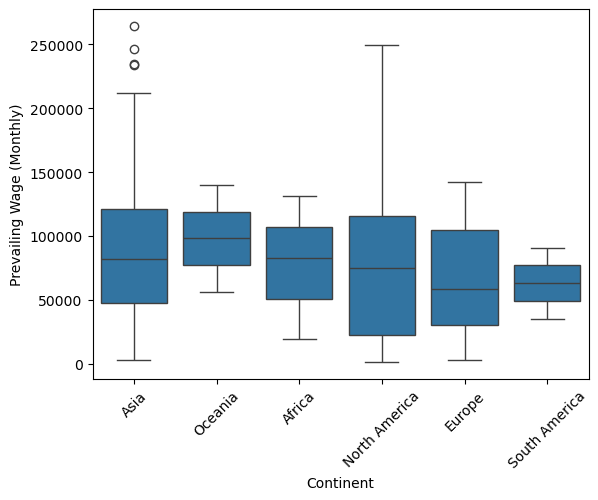

In [66]:
# Continent v Monthly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Month'],
    x='continent',
    y='prevailing_wage'
)
plt.xlabel('Continent')
plt.ylabel('Prevailing Wage (Monthly)')
plt.xticks(rotation=45)
plt.show()

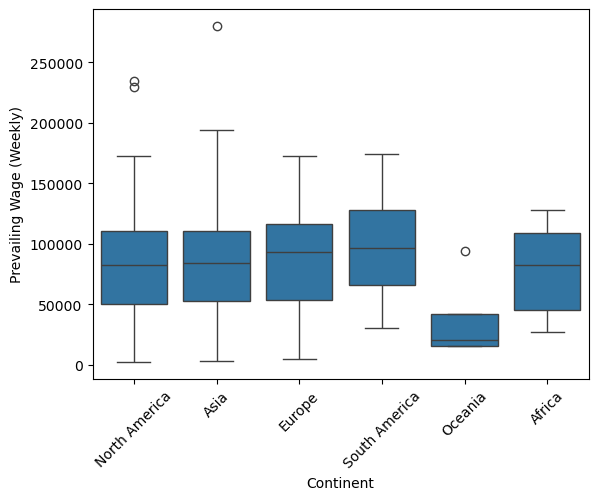

In [67]:
# Continent v Weekly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Week'],
    x='continent',
    y='prevailing_wage'
)
plt.xlabel('Continent')
plt.ylabel('Prevailing Wage (Weekly)')
plt.xticks(rotation=45)
plt.show()

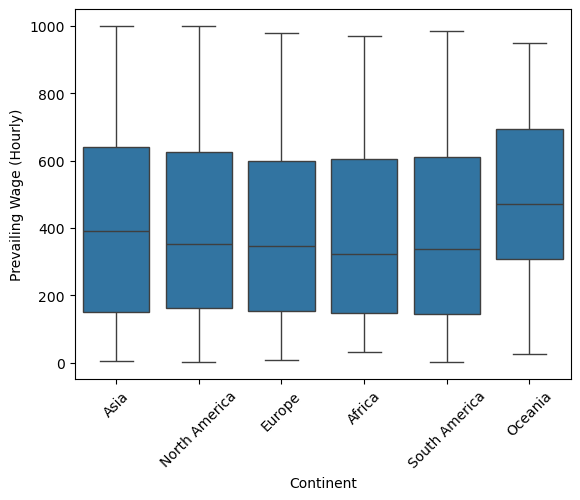

In [68]:
# Continent v Hourly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Hour'],
    x='continent',
    y='prevailing_wage'
)
plt.xlabel('Continent')
plt.ylabel('Prevailing Wage (Hourly)')
plt.xticks(rotation=45)
plt.show()

#### Continent v Full Time Position

In [69]:
#Continent vs. Full Time
pd.crosstab(
    df['continent'],
    df['full_time_position'],
    normalize='index'
)

full_time_position,N,Y
continent,,
Africa,0.056261,0.943739
Asia,0.115118,0.884882
Europe,0.030815,0.969185
North America,0.173451,0.826549
Oceania,0.093750,0.906250
South America,0.036385,0.963615


#### Continent v Case Status

In [70]:
#Continent vs Status
pd.crosstab(
    df['continent'],
    df['case_status'],
    normalize='index'
)

case_status,Certified,Denied
continent,,
Africa,0.720508,0.279492
Asia,0.653105,0.346895
Europe,0.792337,0.207663
North America,0.618773,0.381227
Oceania,0.635417,0.364583
South America,0.578638,0.421362


**Continent Multivariate Observations**
- Across all continents, the majority of applicants have either a Bachelor's or Master's level education.
- Across all continents, the majority of applicants have job experience
- Across all continents, the majority of applicants do not require training
- Across all continents, the majority of applicants are for a yearly wage type role
- Applications from Europe have the lowest average yearly and monthly wages while Oceania has the lowest average weekly wages and Africa the lowest average hourly wages.
- Across all continents, the majority of applicants are for full time positions ranging by continent from 82.6% to 96.4%
- Europe has the highest proportion of applications approved (79.2%) while South America has the lowest (57.9%) **(Leading Question 1)**

### Education Level Multivariate

#### Education v Job Experience

In [71]:
#Education vs. Job Experience
pd.crosstab(
    df['education_of_employee'],
    df['has_job_experience'],
    normalize='index'
)

has_job_experience,N,Y
education_of_employee,,
Bachelor's,0.424858,0.575142
Doctorate,0.429288,0.570712
High School,0.408187,0.591813
Master's,0.414470,0.585530


#### Education v Requires Training

In [72]:
#Education vs Job Training Required
pd.crosstab(
    df['education_of_employee'],
    df['requires_job_training'],
    normalize='index'
)

requires_job_training,N,Y
education_of_employee,,
Bachelor's,0.876588,0.123412
Doctorate,0.811131,0.188869
High School,0.874269,0.125731
Master's,0.911978,0.088022


#### Education v Region of Employment

In [73]:
#Education vs Region
pd.crosstab(
    df['education_of_employee'],
    df['region_of_employment'],
    normalize='index'
)

region_of_employment,Island,Midwest,Northeast,South,West
education_of_employee,,,,,
Bachelor's,0.012605,0.128493,0.280829,0.292261,0.285812
Doctorate,0.011405,0.116788,0.299270,0.246807,0.325730
High School,0.017544,0.215205,0.264620,0.273099,0.229532
Master's,0.016712,0.207598,0.286485,0.264791,0.224414


#### Education v Wage Type

In [74]:
#Education vs Wage Type
pd.crosstab(
    df['education_of_employee'],
    df['unit_of_wage'],
    normalize='index'
)

unit_of_wage,Hour,Month,Week,Year
education_of_employee,,,,
Bachelor's,0.095857,0.004006,0.012312,0.887825
Doctorate,0.043796,0.002281,0.003650,0.950274
High School,0.115497,0.003801,0.009357,0.871345
Master's,0.071102,0.003114,0.011003,0.914781


#### Education v Wage (by wage type)

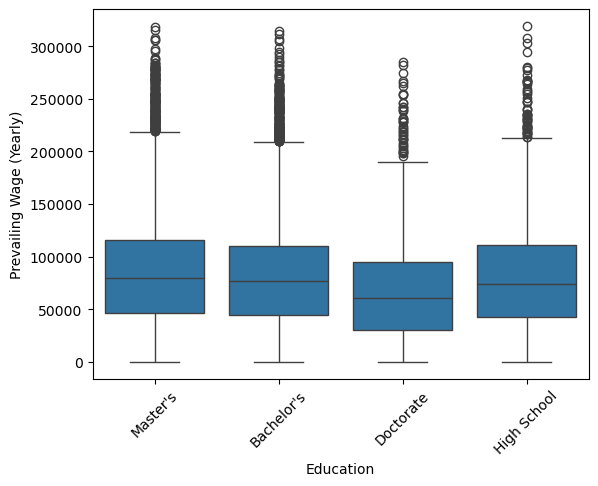

In [75]:
# Education v Yearly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Year'],
    x='education_of_employee',
    y='prevailing_wage'
)
plt.xlabel('Education')
plt.ylabel('Prevailing Wage (Yearly)')
plt.xticks(rotation=45)
plt.show()

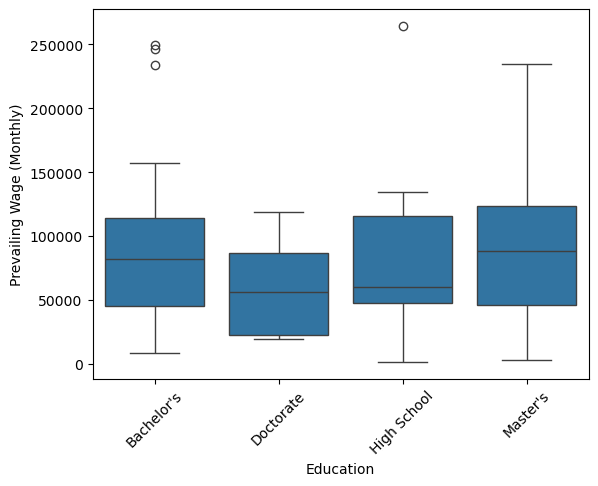

In [76]:
# Education v Monthly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Month'],
    x='education_of_employee',
    y='prevailing_wage'
)
plt.xlabel('Education')
plt.ylabel('Prevailing Wage (Monthly)')
plt.xticks(rotation=45)
plt.show()

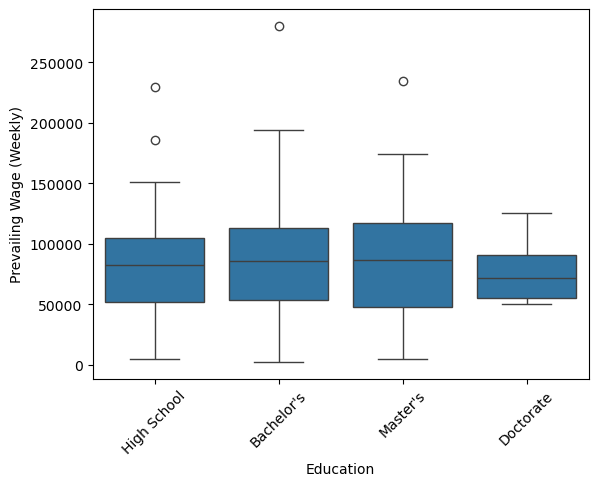

In [77]:
# Education v Weekly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Week'],
    x='education_of_employee',
    y='prevailing_wage'
)
plt.xlabel('Education')
plt.ylabel('Prevailing Wage (Weekly)')
plt.xticks(rotation=45)
plt.show()

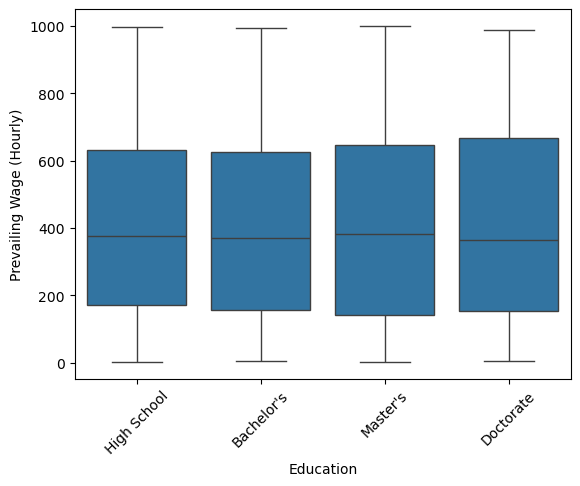

In [78]:
# Education v Hourly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Hour'],
    x='education_of_employee',
    y='prevailing_wage'
)
plt.xlabel('Education')
plt.ylabel('Prevailing Wage (Hourly)')
plt.xticks(rotation=45)
plt.show()

#### Education v Full Time

In [79]:
#Education vs Full Time Roles
pd.crosstab(
    df['education_of_employee'],
    df['full_time_position'],
    normalize='index'
)

full_time_position,N,Y
education_of_employee,,
Bachelor's,0.066738,0.933262
Doctorate,0.036496,0.963504
High School,0.060234,0.939766
Master's,0.180403,0.819597


#### Education v Case Status

In [80]:
#Education vs Status
pd.crosstab(
    df['education_of_employee'],
    df['case_status'],
    normalize='index'
)

case_status,Certified,Denied
education_of_employee,,
Bachelor's,0.622142,0.377858
Doctorate,0.872263,0.127737
High School,0.340351,0.659649
Master's,0.786278,0.213722


**Education Multivariate Observations**
- Job experience is fairly even across education levels with 57-59% having experience at each education level.
- Job Training requirement is fairly even across education levels with 81-91% not requiring training at each level.  Doctorate's are associated with the highest percent needing training at 18.9%
- High School and Master's Degrees have a slightly higher percent of applicants to the Midwest region (16.7% & 17.5%) than Bachelor's and Doctorate's (12.6% & 11.4%)
- As might be expected, high school education has a slightly higher percent of hourly wages at 11.5% of the group.  Doctorate's have the highest percent of the group as yearly wages at 95.0%
- Somewhat surprisingly, across wage types Doctorate's appear to have the lowest average wages.
- Master's has the highest percent applying for non- full time roles at 18.0%
- Doctorate's have the highest approval rate at 87.2% while High School Education has the lowest at 34.0% **(Leading Question 2)**

### Job Experience Multivariate

#### Experience v Training Required

In [81]:
#Experience vs Training Required
pd.crosstab(
    df['has_job_experience'],
    df['requires_job_training'],
    normalize='index'
)

requires_job_training,N,Y
has_job_experience,,
N,0.841731,0.158269
Y,0.914539,0.085461


#### Experience v Company Age

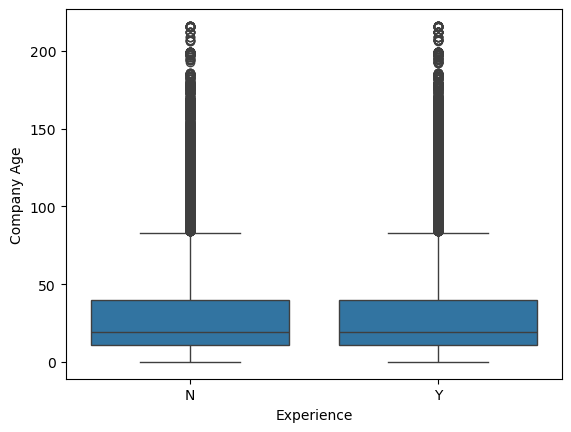

In [82]:
# Experience v Company Age
sns.boxplot(
    df,
    x='has_job_experience',
    y='company_age'
)
plt.xlabel('Experience')
plt.ylabel('Company Age')
plt.show()

#### Experience v Region of Employment

In [83]:
#Experience vs Region
pd.crosstab(
    df['has_job_experience'],
    df['region_of_employment'],
    normalize='index'
)

region_of_employment,Island,Midwest,Northeast,South,West
has_job_experience,,,,,
N,0.014516,0.183930,0.274771,0.273459,0.253325
Y,0.014863,0.158289,0.287867,0.276787,0.262194


#### Experience v Wage Type

In [84]:
#Experience vs Wage Type
pd.crosstab(
    df['has_job_experience'],
    df['unit_of_wage'],
    normalize='index'
)

unit_of_wage,Hour,Month,Week,Year
has_job_experience,,,,
N,0.127833,0.002997,0.006836,0.862334
Y,0.053506,0.003851,0.013444,0.929199


#### Experience v Wage (by wage type)

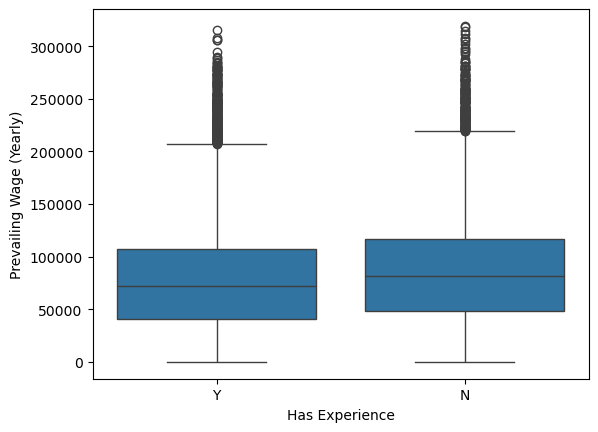

In [85]:
# Experience v Yearly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Year'],
    x='has_job_experience',
    y='prevailing_wage'
)
plt.xlabel('Has Experience')
plt.ylabel('Prevailing Wage (Yearly)')
plt.show()

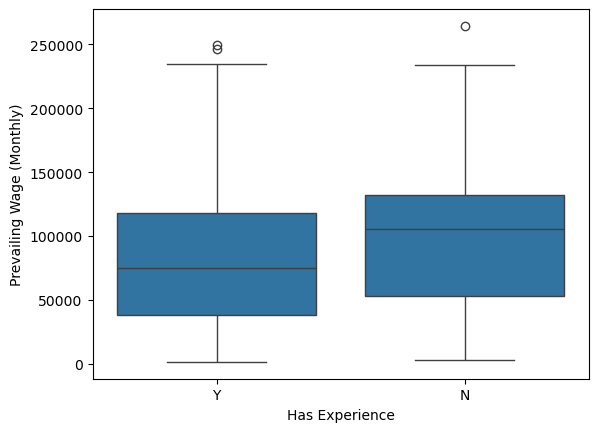

In [86]:
# Experience v Monthly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Month'],
    x='has_job_experience',
    y='prevailing_wage'
)
plt.xlabel('Has Experience')
plt.ylabel('Prevailing Wage (Monthly)')
plt.show()

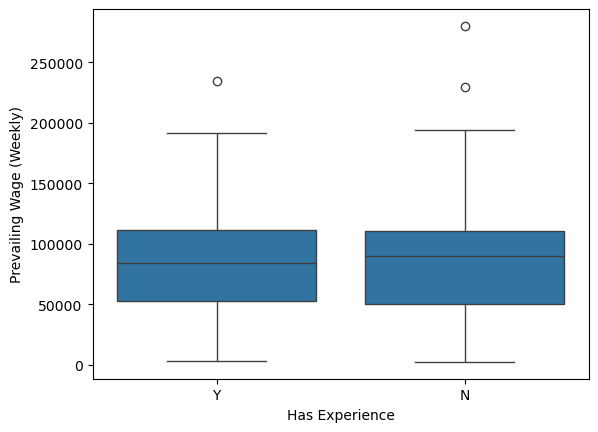

In [87]:
# Experience v Weekly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Week'],
    x='has_job_experience',
    y='prevailing_wage'
)
plt.xlabel('Has Experience')
plt.ylabel('Prevailing Wage (Weekly)')
plt.show()

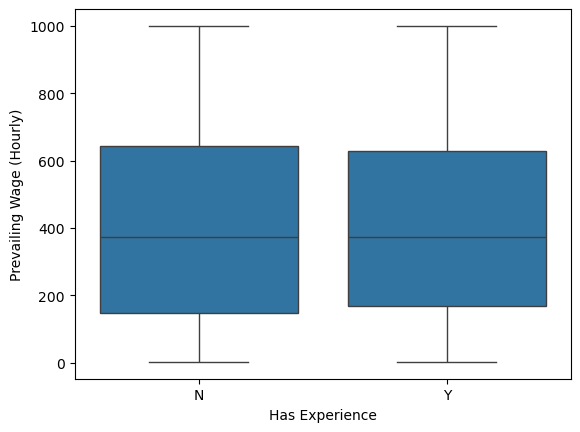

In [88]:
# Experience v Hourly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Hour'],
    x='has_job_experience',
    y='prevailing_wage'
)
plt.xlabel('Has Experience')
plt.ylabel('Prevailing Wage (Hourly)')
plt.show()

#### Experience v Full Time

In [89]:
#Experience vs Full Time Roles
pd.crosstab(
    df['has_job_experience'],
    df['full_time_position'],
    normalize='index'
)

full_time_position,N,Y
has_job_experience,,
N,0.121465,0.878535
Y,0.095257,0.904743


#### Experience v Case Status

In [90]:
#Experience vs Status
pd.crosstab(
    df['has_job_experience'],
    df['case_status'],
    normalize='index'
)

case_status,Certified,Denied
has_job_experience,,
N,0.561341,0.438659
Y,0.744764,0.255236


**Job Experience Multivariate Observations**
- As might be expected, applicants with job experience are less likely to require job training (8.5% vs 15.8% require training).
- Company age does not seem to have an impact on attracting experience nor does region to any appreciable degree.
- As expected, applicants with experience have a higher percent earning a yearly wage (92.9% v 86.2%) while those with no experience have a higher percent in the hourly bucket (12.8% v 5.4%)
- Surprisingly, applicants with no experience appear to be for equal or higher wages on average than those with experience.
- Case status appears to be heavily influenced by job experience with a 74.5% approval rate for those with experience vs a 56.1% approval rate for those without. **(Leading Question 3)**

### Job Training Required Multivariate

#### Training Required v Region

In [91]:
#Requires Training vs Region
pd.crosstab(
    df['requires_job_training'],
    df['region_of_employment'],
    normalize='index'
)

region_of_employment,Island,Midwest,Northeast,South,West
requires_job_training,,,,,
N,0.015671,0.180866,0.292519,0.260910,0.250033
Y,0.007445,0.078849,0.205076,0.385787,0.322843


#### Training Required v Wage Type

In [92]:
#Requires Training vs Region
pd.crosstab(
    df['requires_job_training'],
    df['unit_of_wage'],
    normalize='index'
)

unit_of_wage,Hour,Month,Week,Year
requires_job_training,,,,
N,0.092608,0.003774,0.011853,0.891765
Y,0.024027,0.001354,0.001692,0.972927


#### Training Required v Wage earned (by wage type)

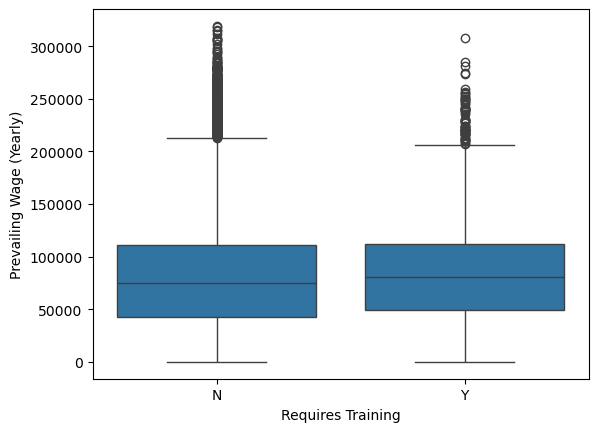

In [93]:
# Training Required v Yearly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Year'],
    x='requires_job_training',
    y='prevailing_wage'
)
plt.xlabel('Requires Training')
plt.ylabel('Prevailing Wage (Yearly)')
plt.show()

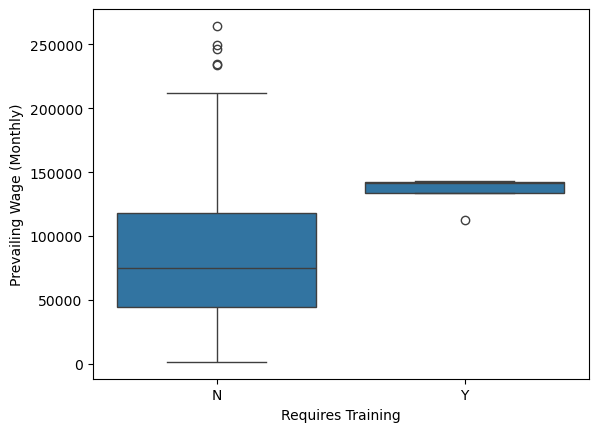

In [94]:
# Training Required v Monthly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Month'],
    x='requires_job_training',
    y='prevailing_wage'
)
plt.xlabel('Requires Training')
plt.ylabel('Prevailing Wage (Monthly)')
plt.show()

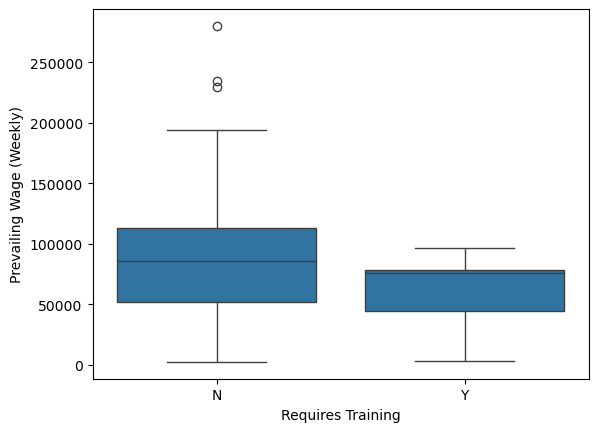

In [95]:
# Training Required v Weekly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Week'],
    x='requires_job_training',
    y='prevailing_wage'
)
plt.xlabel('Requires Training')
plt.ylabel('Prevailing Wage (Weekly)')
plt.show()

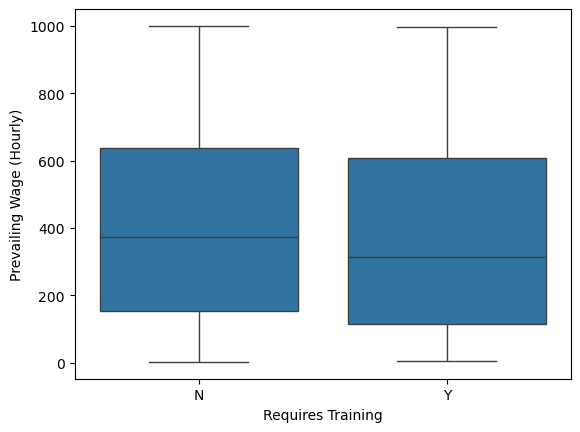

In [96]:
# Training Required v Hourly Wages
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Hour'],
    x='requires_job_training',
    y='prevailing_wage'
)
plt.xlabel('Requires Training')
plt.ylabel('Prevailing Wage (Hourly)')
plt.show()

#### Training Required v Full Time Roles

In [97]:
#Requires Training vs Full Time
pd.crosstab(
    df['requires_job_training'],
    df['full_time_position'],
    normalize='index'
)

full_time_position,N,Y
requires_job_training,,
N,0.117913,0.882087
Y,0.017259,0.982741


#### Training Required v Case Status

In [98]:
#Requires Training vs Status
pd.crosstab(
    df['requires_job_training'],
    df['case_status'],
    normalize='index'
)

case_status,Certified,Denied
requires_job_training,,
N,0.666459,0.333541
Y,0.678849,0.321151


**Job Training Required Multivariate Observations**
- Applications requiring job training seem to concentrate slightly higher in the West and South regions
- Overall, job training requirement does not appear to have a major impact on wages in this group. Those requiring training earn slightly higher on average in the monthly bucket, slightly lower in the weekly and fairly comparable in the Hourly and Yearly.
- More people require training for the full time applications (98.3%) than non-full time (88.2%)
- Case outcomes are quite even with those not requiring training approved at a rate of 66.7% and those requiring training at a rate of 67.9% - both in line with overall outcomes as well.

### Number of Employees Multivariate

#### Number of Employees v Company Age

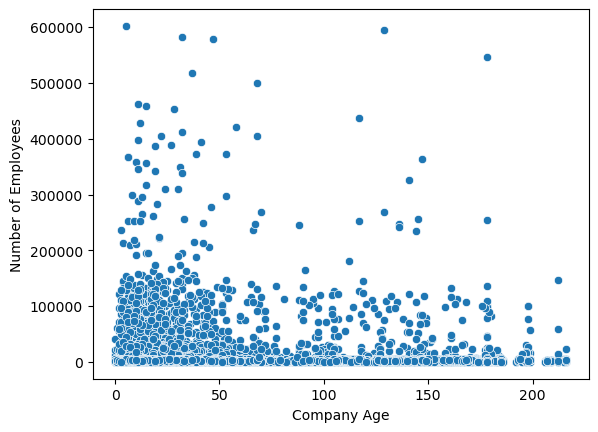

In [99]:
#Number of Employees vs Company Age
sns.scatterplot(
    df, 
    x="company_age", 
    y="no_of_employees"
)
plt.xlabel('Company Age')
plt.ylabel('Number of Employees')
plt.show()

#### Number of Employees v Region

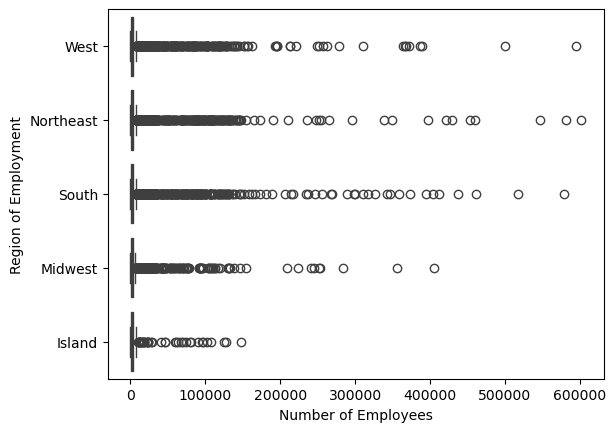

In [100]:
# Number of Employees v Region
sns.boxplot(
    df,
    x='no_of_employees',
    y='region_of_employment'
)
plt.xlabel('Number of Employees')
plt.ylabel('Region of Employment')
plt.show()

#### Number of Employees v Wage Type

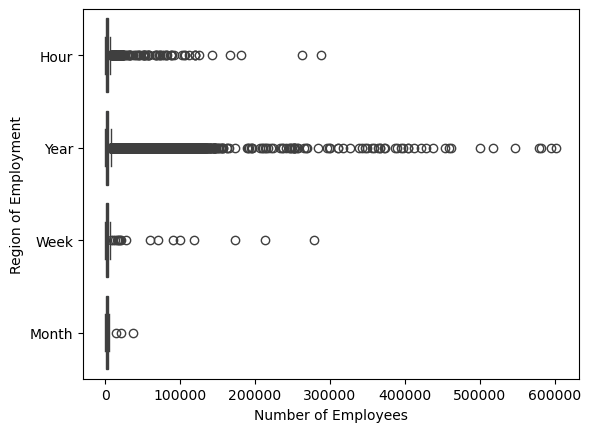

In [101]:
# Number of Employees v Region
sns.boxplot(
    df,
    x='no_of_employees',
    y='unit_of_wage'
)
plt.xlabel('Number of Employees')
plt.ylabel('Region of Employment')
plt.show()

In [102]:
#Get biggest company with Hourly wage
df[df['unit_of_wage'] == 'Hour']['no_of_employees'].max()

288512

In [103]:
#Get biggest company with Weekly wage
df[df['unit_of_wage'] == 'Week']['no_of_employees'].max()

278152

#### Number of Employees v Wage (by wage type)

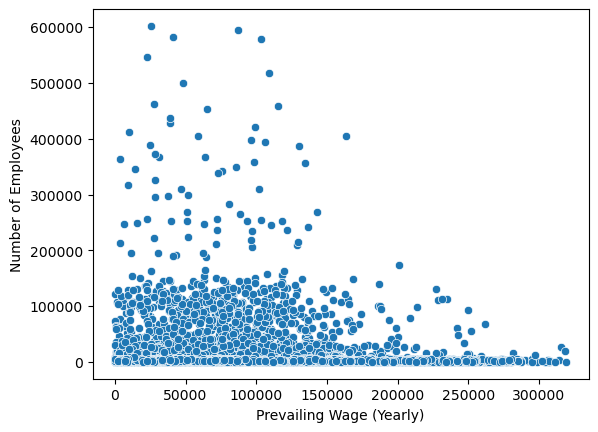

In [104]:
#Number of Employees vs Yearly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Year'], 
    x="prevailing_wage", 
    y="no_of_employees"
)
plt.xlabel('Prevailing Wage (Yearly)')
plt.ylabel('Number of Employees')
plt.show()

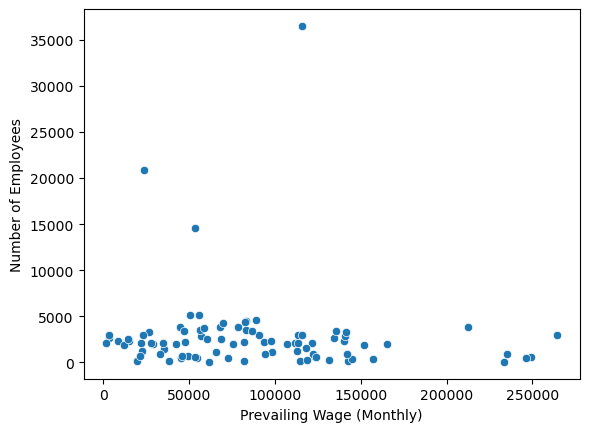

In [105]:
#Number of Employees vs Monthly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Month'], 
    x="prevailing_wage", 
    y="no_of_employees"
)
plt.xlabel('Prevailing Wage (Monthly)')
plt.ylabel('Number of Employees')
plt.show()

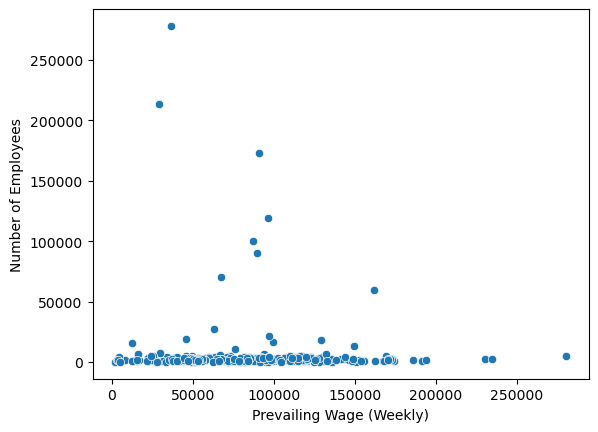

In [106]:
#Number of Employees vs Weekly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Week'], 
    x="prevailing_wage", 
    y="no_of_employees"
)
plt.xlabel('Prevailing Wage (Weekly)')
plt.ylabel('Number of Employees')
plt.show()

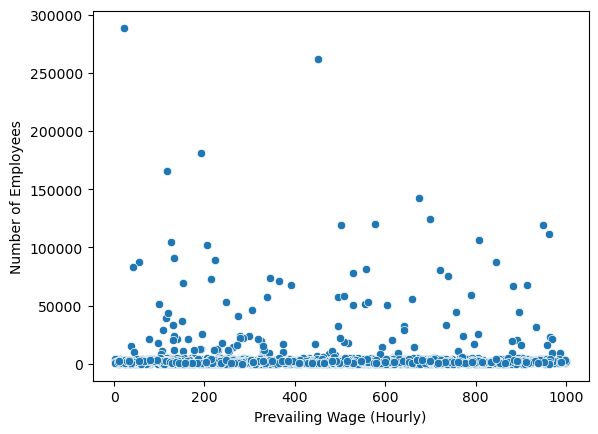

In [107]:
#Number of Employees vs Hourly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Hour'], 
    x="prevailing_wage", 
    y="no_of_employees"
)
plt.xlabel('Prevailing Wage (Hourly)')
plt.ylabel('Number of Employees')
plt.show()

#### Number of Employees v Case Status

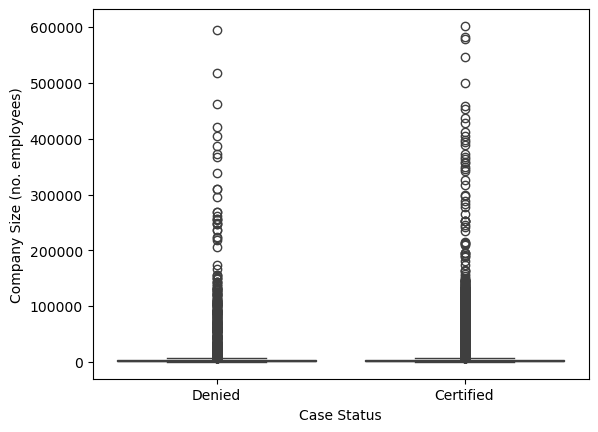

In [108]:
# Company Size v Case Status
sns.boxplot(
    df,
    x='case_status',
    y='no_of_employees'
)
plt.xlabel('Case Status')
plt.ylabel('Company Size (no. employees)')
plt.show()

In [109]:
describe_distribution(df[df['case_status'] == 'Denied'], 'no_of_employees')

Lower Outlier Fence = -2602.625
Upper Outlier Fence = 6980.375
Outlier count: 495
Skewness:  12.423782128335535
The distribution is highly skewed to the right.


count      8462.000000
mean       5385.601040
std       22382.740832
min          11.000000
25%         991.000000
50%        2032.500000
75%        3386.750000
max      594472.000000
Name: no_of_employees, dtype: float64

In [110]:
describe_distribution(df[df['case_status'] == 'Certified'], 'no_of_employees')

Lower Outlier Fence = -2774.375
Upper Outlier Fence = 7384.625
Outlier count: 1057
Skewness:  12.189543902114702
The distribution is highly skewed to the right.


count     17018.000000
mean       5807.055882
std       23119.565783
min          11.000000
25%        1035.250000
50%        2147.000000
75%        3575.000000
max      602069.000000
Name: no_of_employees, dtype: float64

**Number of Employees Multivariate Observations**
- We can see again what the heatmap showed earlier - almost no correlation between company age and number of employees.
- As expected company size clusters on the small end, but with many outliers.  The West, Northeast, and South skew larger.
- In this data set, every application for a company above 288,512 employees has a yearly wage type.
- As seen in the heatmap, there is virtually no correlation between company size and wage.
- Certified and denied applications have extremely similar distributions across company sizes. **(Leading Question 6)**

### Company Age Multivariate

#### Company Age v Region

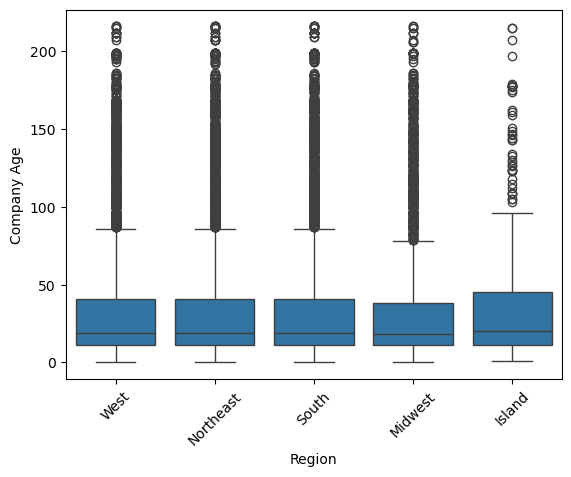

In [111]:
# Company Age v Region
sns.boxplot(
    df,
    x='region_of_employment',
    y='company_age'
)
plt.xlabel('Region')
plt.ylabel('Company Age')
plt.xticks(rotation=45)
plt.show()

#### Company Age v Wage Type

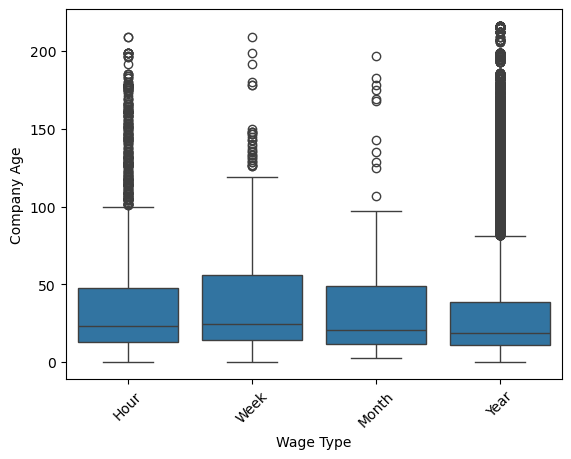

In [112]:
# Company Age v Wage Type
wage_type_order= [
    "Hour",
    "Week",
    "Month",
    "Year"
    ]

sns.boxplot(
    df,
    x='unit_of_wage',
    y='company_age',
    order = wage_type_order
)
plt.xlabel('Wage Type')
plt.ylabel('Company Age')
plt.xticks(rotation=45)
plt.show()

#### Company Age v Wage (by wage type)

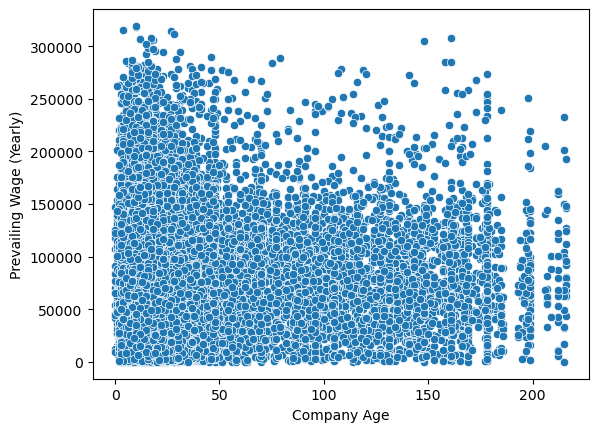

In [113]:
#Company Age vs Yearly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Year'], 
    x="company_age", 
    y="prevailing_wage"
)
plt.xlabel('Company Age')
plt.ylabel('Prevailing Wage (Yearly)')
plt.show()

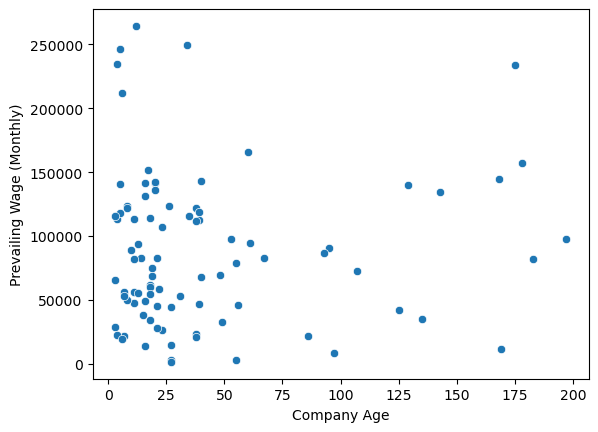

In [114]:
#Company Age vs Monthly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Month'], 
    x="company_age", 
    y="prevailing_wage"
)
plt.xlabel('Company Age')
plt.ylabel('Prevailing Wage (Monthly)')
plt.show()

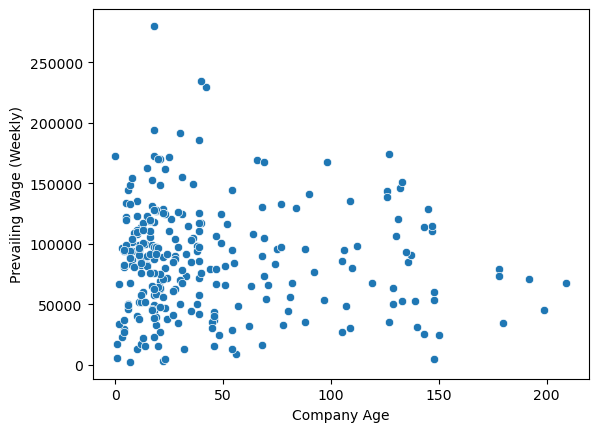

In [115]:
#Company Age vs Weekly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Week'], 
    x="company_age", 
    y="prevailing_wage"
)
plt.xlabel('Company Age')
plt.ylabel('Prevailing Wage (Weekly)')
plt.show()

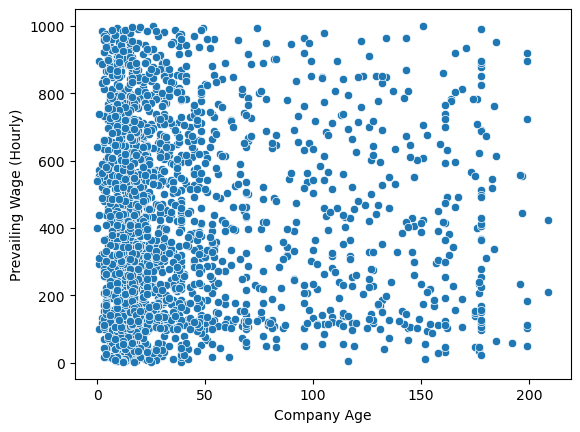

In [116]:
#Company Age vs Hourly Wages
sns.scatterplot(
    data=df[df['unit_of_wage'] == 'Hour'], 
    x="company_age", 
    y="prevailing_wage"
)
plt.xlabel('Company Age')
plt.ylabel('Prevailing Wage (Hourly)')
plt.show()

#### Company Age v Full Time Role

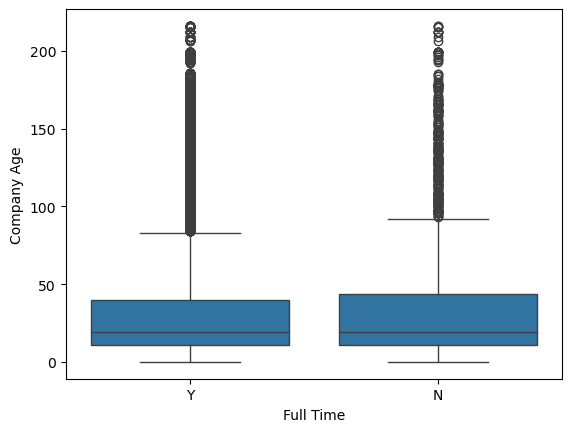

In [117]:
#Company Age vs Full Time
sns.boxplot(
    df,
    x='full_time_position',
    y='company_age'
)
plt.xlabel('Full Time')
plt.ylabel('Company Age')
plt.show()

#### Company Age v Case Status

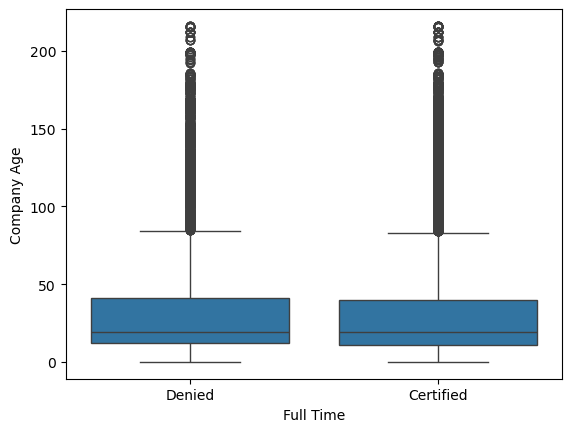

In [118]:
#Company Age vs Status
sns.boxplot(
    df,
    x='case_status',
    y='company_age'
)
plt.xlabel('Full Time')
plt.ylabel('Company Age')
plt.show()

In [119]:
describe_distribution(df[df['case_status'] == 'Denied'], 'company_age')

Lower Outlier Fence = -31.5
Upper Outlier Fence = 84.5
Outlier count: 1075
Skewness:  2.0429020206714936
The distribution is highly skewed to the right.


count    8462.000000
mean       37.106594
std        42.541819
min         0.000000
25%        12.000000
50%        19.000000
75%        41.000000
max       216.000000
Name: company_age, dtype: float64

In [120]:
describe_distribution(df[df['case_status'] == 'Certified'], 'company_age')

Lower Outlier Fence = -32.5
Upper Outlier Fence = 83.5
Outlier count: 2173
Skewness:  2.034720349099235
The distribution is highly skewed to the right.


count    17018.000000
mean        36.333235
std         42.278601
min          0.000000
25%         11.000000
50%         19.000000
75%         40.000000
max        216.000000
Name: company_age, dtype: float64

**Company Age Multivariate Observations**
- Company Age is fairly evenly spread across regions.
- There is a fairly even distribution of company ages across wage types.
- There is no correlation noted between company age (or year of establishment) and Wage
- There is no obvious relationship between full time roles and company age
- The company age distributions for both approved and denied applications are extremely similar

### Region of Employment Multivariate

#### Region v Wage Type

In [121]:
#Region vs Wage Type
pd.crosstab(
    df['region_of_employment'],
    df['unit_of_wage'],
    normalize='index'
)

unit_of_wage,Hour,Month,Week,Year
region_of_employment,,,,
Island,0.048000,0.000000,0.008000,0.944000
Midwest,0.033898,0.003018,0.007430,0.955654
Northeast,0.120222,0.004031,0.012787,0.862960
South,0.099188,0.003990,0.009691,0.887131
West,0.065594,0.002885,0.011691,0.919830


#### Region v Wage (by wage type)

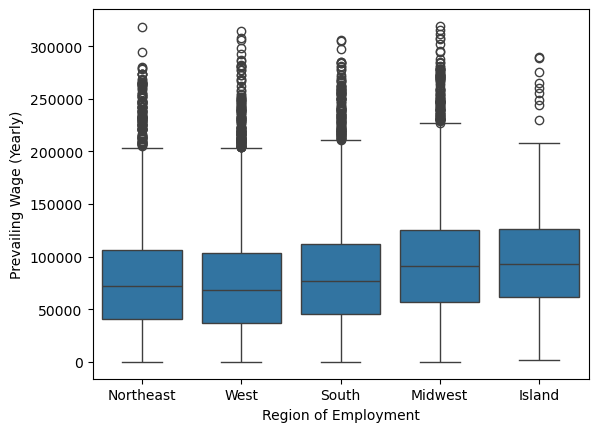

In [122]:
# Region vs Yearly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Year'],
    x='region_of_employment',
    y='prevailing_wage'
)
plt.xlabel('Region of Employment')
plt.ylabel('Prevailing Wage (Yearly)')
plt.show()

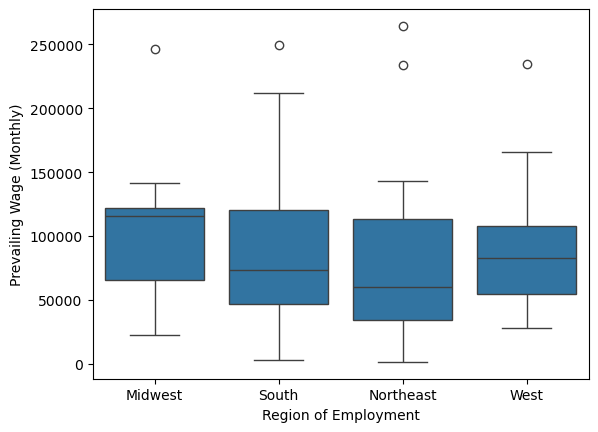

In [123]:
# Region vs Monthly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Month'],
    x='region_of_employment',
    y='prevailing_wage'
)
plt.xlabel('Region of Employment')
plt.ylabel('Prevailing Wage (Monthly)')
plt.show()

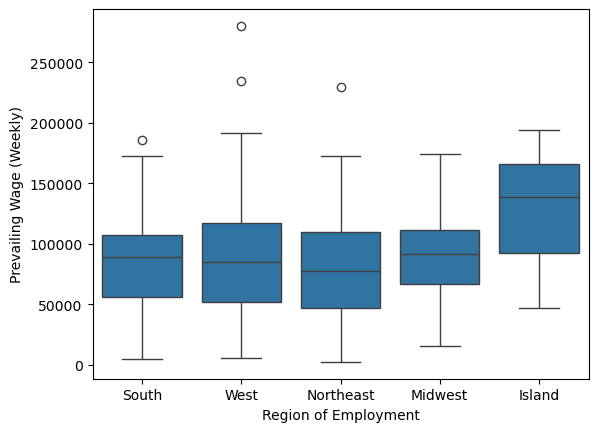

In [124]:
# Region vs Weekly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Week'],
    x='region_of_employment',
    y='prevailing_wage'
)
plt.xlabel('Region of Employment')
plt.ylabel('Prevailing Wage (Weekly)')
plt.show()

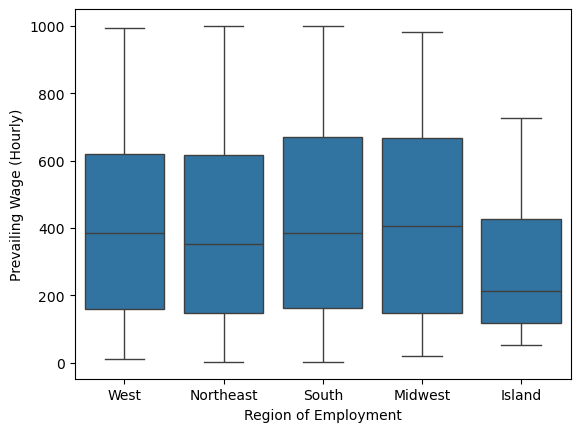

In [125]:
# Region vs Hourly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Hour'],
    x='region_of_employment',
    y='prevailing_wage'
)
plt.xlabel('Region of Employment')
plt.ylabel('Prevailing Wage (Hourly)')
plt.show()

#### Region v Full Time

In [126]:
#Region vs Full Time
pd.crosstab(
    df['region_of_employment'],
    df['full_time_position'],
    normalize='index'
)

full_time_position,N,Y
region_of_employment,,
Island,0.120000,0.880000
Midwest,0.104481,0.895519
Northeast,0.111744,0.888256
South,0.133248,0.866752
West,0.071819,0.928181


#### Region v Case Status

In [127]:
#Region vs Status
pd.crosstab(
    df['region_of_employment'],
    df['case_status'],
    normalize='index'
)

case_status,Certified,Denied
region_of_employment,,
Island,0.602667,0.397333
Midwest,0.755282,0.244718
Northeast,0.629048,0.370952
South,0.700157,0.299843
West,0.622533,0.377467


**Region of Employment Multivariate Observations**
- Across all regions of employment the dominant wage type is Yearly
- Averge wages vary slightly by region and wage type.
- There are no monthly wages in the Island region.
- Agross regions the majority of positions are full-time ranging from 86.7% (South) -92.8% (West)
- Midwest region has the highest percent of cases approved (75.5%) while Island region has the lowest percent approved (60.3%) **(Leading Question 5)**

### Unit of Wage Multivariate

#### Wage Ranges by Wage Type

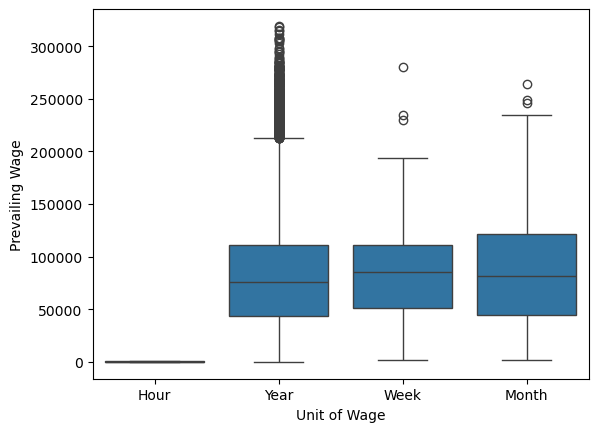

In [128]:
# Wage Range v Type
sns.boxplot(
    df,
    x='unit_of_wage',
    y='prevailing_wage'
)
plt.xlabel('Unit of Wage')
plt.ylabel('Prevailing Wage')
plt.show()

In Line Observation: The comparison of yearly, weekly, and monthly wages are suspiciously similar - we will investigate further before moving on.  Results and decisions will be marked in the observations for this section.

In [129]:
#Describe Weekly Wages
describe_distribution(df[df['unit_of_wage'] == 'Week'], 'prevailing_wage')

Lower Outlier Fence = -38477.171250000014
Upper Outlier Fence = 201217.35875
Outlier count: 3
Skewness:  0.6577113245551544
The distribution is moderately skewed to the right.


count       272.000000
mean      85606.820515
std       44802.704810
min        2183.230000
25%       51408.277500
50%       85075.820000
75%      111331.910000
max      280175.950000
Name: prevailing_wage, dtype: float64

In [130]:
#Describe Monthly Wages
describe_distribution(df[df['unit_of_wage'] == 'Month'], 'prevailing_wage')

Lower Outlier Fence = -69978.80000000002
Upper Outlier Fence = 236594.64
Outlier count: 3
Skewness:  0.9638152264168949
The distribution is moderately skewed to the right.


count        89.000000
mean      87592.864045
std       59525.124924
min        1599.280000
25%       44986.240000
50%       81826.010000
75%      121629.600000
max      264362.950000
Name: prevailing_wage, dtype: float64

In [131]:
#Describe Yearly Wages
describe_distribution(df[df['unit_of_wage'] == 'Year'], 'prevailing_wage')

Lower Outlier Fence = -57723.052499999976
Upper Outlier Fence = 212780.96749999997
Outlier count: 473
Skewness:  0.8655694846937119
The distribution is moderately skewed to the right.


count     22962.000000
mean      81228.077133
std       49951.473223
min         100.000000
25%       43715.955000
50%       76174.500000
75%      111341.960000
max      319210.270000
Name: prevailing_wage, dtype: float64

In [132]:
#Count of Yearly wages less than $15,080
((df['unit_of_wage'] == 'Year') & (df['prevailing_wage'] < 15080)).sum()

np.int64(1586)

In [133]:
#Setup datafram of Yearly wages with column indicating above or below 15080 mark
yearly = df[df['unit_of_wage'] == 'Year'].copy()
yearly['wage_group'] = np.where(
    yearly['prevailing_wage'] < 15080,
    'Below $15,080',
    'At/Above $15,080'
)

yearly.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age,wage_group
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,14,"At/Above $15,080"
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,8,"At/Above $15,080"
3,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,119,"At/Above $15,080"
4,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,11,"At/Above $15,080"
5,Asia,Master's,Y,N,2339,2012,South,78252.14,Year,Y,Certified,4,"At/Above $15,080"


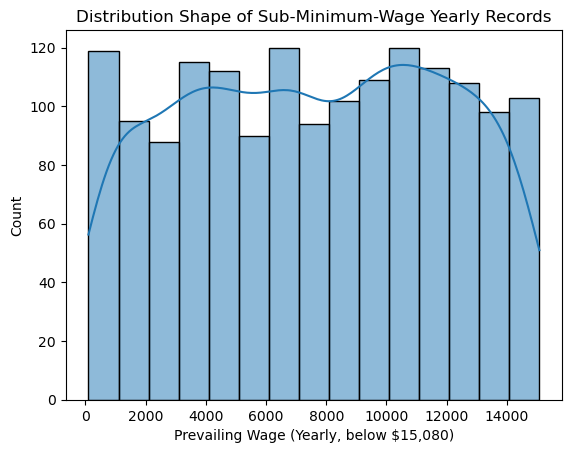

In [134]:
#Histplot of yearly wages below 15,080 
low_wage = yearly[yearly['wage_group'] == 'Below $15,080']

sns.histplot(data=low_wage, x='prevailing_wage', bins=15, kde=True)
plt.xlabel('Prevailing Wage (Yearly, below $15,080)')
plt.ylabel('Count')
plt.title('Distribution Shape of Sub-Minimum-Wage Yearly Records')
plt.show()

In [135]:
#Yearly wage below 15,080 Full Time Status
low_wage['full_time_position'].value_counts(normalize=True) * 100

full_time_position
Y    96.090794
N     3.909206
Name: proportion, dtype: float64

In [136]:
#Yearly wage below 15,080 case status
low_wage['full_time_position'].value_counts(normalize=True) * 100
low_wage['case_status'].value_counts(normalize=True) * 100

case_status
Certified    73.833544
Denied       26.166456
Name: proportion, dtype: float64

#### Type Wage v Full Time Role

In [137]:
#Unit of Wage v. Full Time Role
pd.crosstab(
    df['unit_of_wage'],
    df['full_time_position'],
    normalize='index'
)

full_time_position,N,Y
unit_of_wage,,
Hour,0.008809,0.991191
Month,0.056180,0.943820
Week,0.036765,0.963235
Year,0.116410,0.883590


#### Unit of Wage v Case Status

In [138]:
#Unit of Wage v. Case Status
pd.crosstab(
    df['unit_of_wage'],
    df['case_status'],
    normalize='index'
)

case_status,Certified,Denied
unit_of_wage,,
Hour,0.346314,0.653686
Month,0.617978,0.382022
Week,0.621324,0.378676
Year,0.698850,0.301150


**Unit of Wage Multivariate Observations**

**Problem** Very surprisingly the mean and median wages on a weekly, monthly and yearly basis are extremely close in value.  Perhaps most alarming is the fact that the lowest yearly wage shows as `$100`/yr.  Assuming a federal minimum wage of `$7.25` per hour for a 40 hour work week 52 weeks per year, we can assume the minimum yearly salary is `$15,080` for a full time role.  Monthly that is a minimum of `$1,256.67`.
This implies that on the low end, the yearly wages are the only ones that are lower than is practically possible (considering 96.1% of wages below `$15,080` are for full time roles).  On the high end, there are some shockingly high weekly and monthly wage values.
We would also expect to see rejections at such low wages were they real, but these visas are actually approved at a higher rate than the overall average.

**Decision** We have already seen that this training data has some intentional quirks that appear to have been introduced to arrange certain outcomes.  Additionally, this data makes up 6.9% of the overall set, so rather than treating in a way that will change the project results we will leave these values for now.
- Since it makes no sense to compare an hourly wage to a yearly wage value, we have separated out wage types to view individual distributions.

- This confirms the same finding that appeared in our Hourly-wage investigation: prevailing_wage does not appear to scale meaningfully with unit_of_wage for the Week/Month/Year categories either, further validating our decision not to attempt cross-unit normalization.

**Other Observations**
- Surprisingly (another indicator of potential issues with this data set), yearly wages are associated with the highest percent of non full time roles at 11.6%
- Roles with a yearly wage were Certified at the highest rate (69.9%) while hourly roles had the lowest certification rate (34.6%)

### Wage Amount Multivariate

#### Wage Amount v Full Time Role (by wage type)

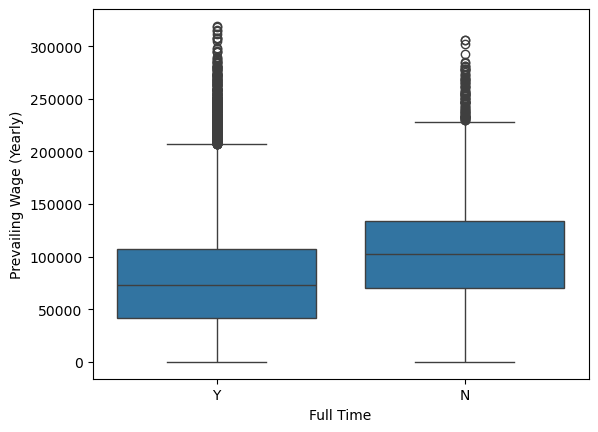

In [139]:
# Full Time vs Yearly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Year'],
    x='full_time_position',
    y='prevailing_wage'
)
plt.xlabel('Full Time')
plt.ylabel('Prevailing Wage (Yearly)')
plt.show()

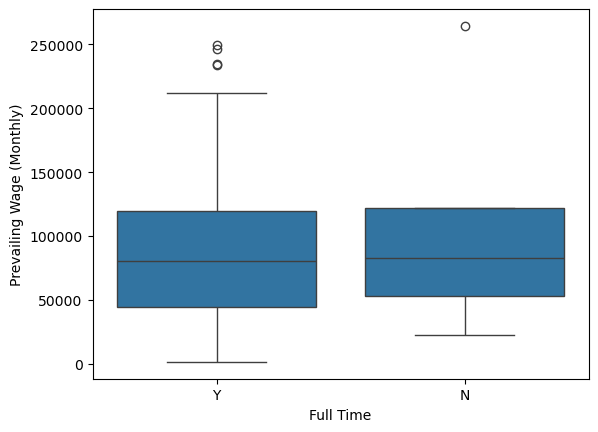

In [140]:
# Full Time vs Monthly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Month'],
    x='full_time_position',
    y='prevailing_wage'
)
plt.xlabel('Full Time')
plt.ylabel('Prevailing Wage (Monthly)')
plt.show()

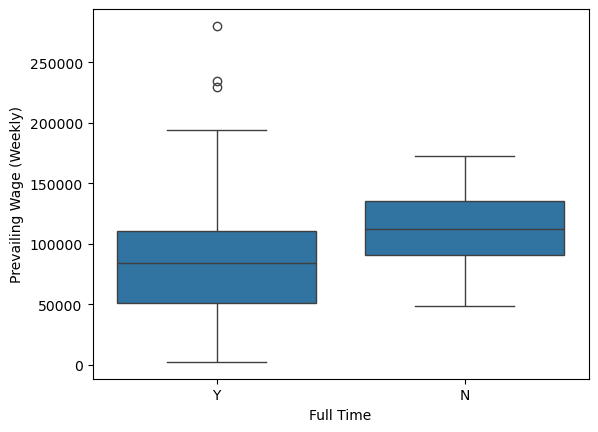

In [141]:
# Full Time vs Weekly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Week'],
    x='full_time_position',
    y='prevailing_wage'
)
plt.xlabel('Full Time')
plt.ylabel('Prevailing Wage (Weekly)')
plt.show()

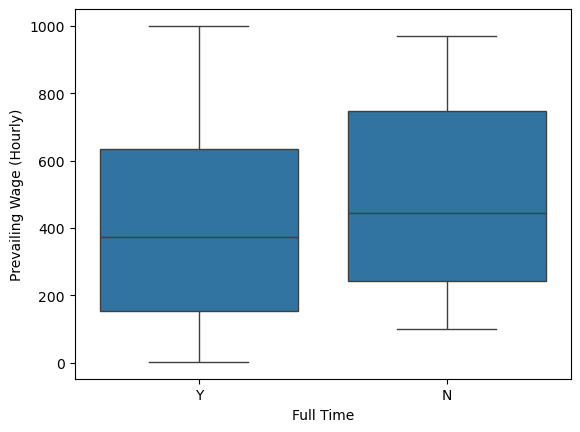

In [142]:
# Full Time vs Hourly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Hour'],
    x='full_time_position',
    y='prevailing_wage'
)
plt.xlabel('Full Time')
plt.ylabel('Prevailing Wage (Hourly)')
plt.show()

#### Wage Amount v Case Status (by wage type)

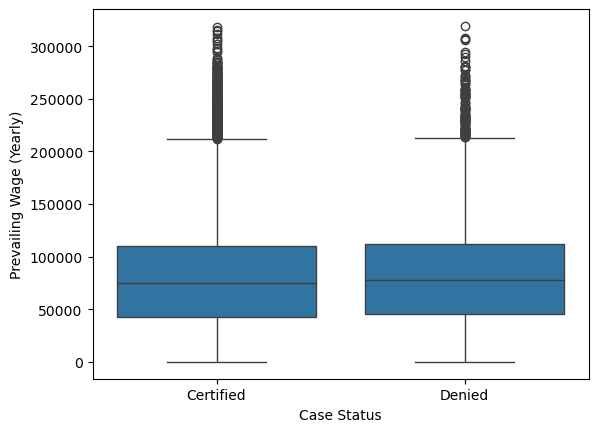

In [143]:
# Case Status vs Yearly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Year'],
    x='case_status',
    y='prevailing_wage'
)
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage (Yearly)')
plt.show()

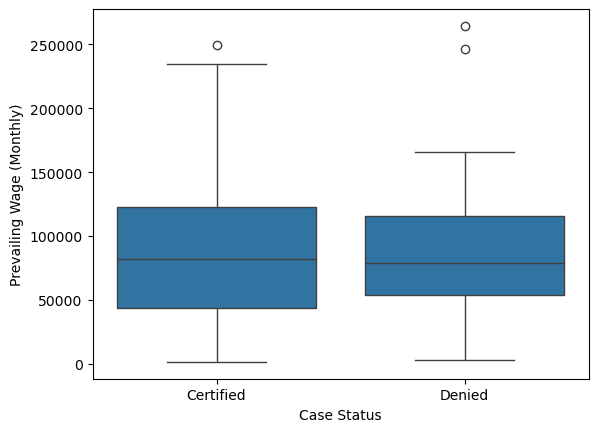

In [144]:
# Case Status vs Monthly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Month'],
    x='case_status',
    y='prevailing_wage'
)
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage (Monthly)')
plt.show()

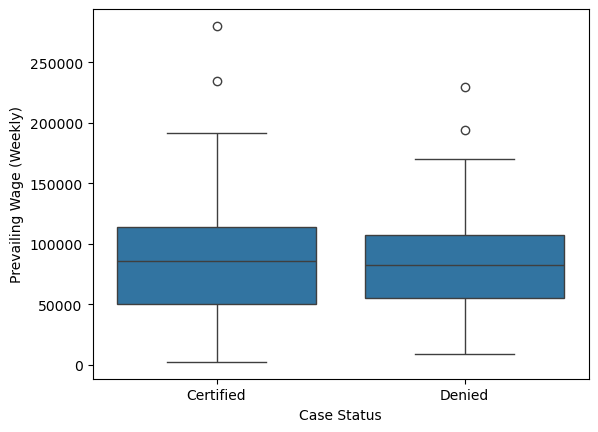

In [145]:
# Case Status vs Weekly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Week'],
    x='case_status',
    y='prevailing_wage'
)
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage (Weekly)')
plt.show()

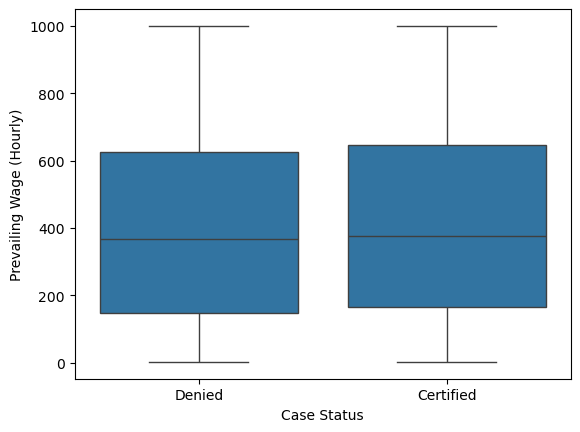

In [146]:
# Case Status vs Hourly Wage
sns.boxplot(
    data=df[df['unit_of_wage'] == 'Hour'],
    x='case_status',
    y='prevailing_wage'
)
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage (Hourly)')
plt.show()

**Wage Amount Multivariate Observations**
- In general the mean wage amount appears to be higher for part time roles, but with a tighter band in several of the wage types.
- The distribution of wages for both approvals and denials look very comparable across wage types. **(Leading Question 4)**

### Full Time Position Multivariate

#### Full Time v Case Status

In [147]:
#Full Time vs Case Status
pd.crosstab(
    df['full_time_position'],
    df['case_status'],
    normalize='index'
)

case_status,Certified,Denied
full_time_position,,
N,0.685260,0.314740
Y,0.665832,0.334168


**Full Time Position Multivariate Observations**
- Full Time and Part Time roles appear to have similar approval rates with 66.6% for full time and 68.5% for part time.

### EDA Final Observations

- Overall 66.8% of applications were approved and certified.
    - Doctorate's have the highest approval rate at 87.2% while High School Education has the lowest at 34.0%
    - Europe has the highest proportion of applications approved (79.2%) while South America has the lowest (57.9%)
    - There is a 74.5% approval rate for those with job experience vs a 56.1% approval rate for those without
    - Midwest region has the highest percent of cases approved (75.5%) while Island region has the lowest percent approved (60.3%) (small sample size at only .8% of data — interpret cautiously)
    - Roles with a yearly wage were Certified at the highest rate (69.9%) while hourly roles had the lowest certification rate (34.6%)
- Surprisingly, applicants with no experience appear to be for equal or higher wages on average than those with experience.
- Notable Data imbalances: 
    - 90.1% of applications in the data are for yearly unit of wage.
    - 88.4% of applications do not require job training
    - 80.3% of applications are for full time positions.
    - The vast majority of applications are out of Asia (66.2%) with the next highest continent being Europe at 14.6%.
- Potential indicators of bad data:
    - 6.9% of dataset represents yearly wage roles paid under the national minimum wage
    - A significant amount of Monthly and Weekly wages are unrealistically high (ie 50% of Monthly wages > `$76,174` per month; 50% of weekly wages > `$85,075` per week.
    - Yearly wages are associated with the highest percent of part time roles at 11.6% of yearly wages associated with roles that are not full time
    - Overall, prevailing_wage does not appear to scale meaningfully with unit_of_wage, making any attempt cross-unit normalization practically meaningless.


# **Data Pre-processing**

In [148]:
#Drop yr_of_estab since it is now redundant with company_age
df = df.drop('yr_of_estab', axis=1)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,9
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,14
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,8
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,119
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,11


In [149]:
# Encode case_status: 1 = Certified, 0 = Denied
if df['case_status'].dtype == 'object':
    df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,0,9
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,1,14
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,0,8
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,0,119
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,1,11


**Design Choice Note:** 
Normally we would set the minority class (Denied) to 1.  However, in this case we are assuming application default states are Denied and we are attempting to identify those applications that clear the bar of Approval, so we will set Approval = 1

In [150]:
# Split dependent and Independent Variables
X = df.drop(["case_status"], axis=1)
y = df["case_status"]

In [151]:
#Get dummy variables for object variables
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

In [152]:
#Check X Set
X.head()

,no_of_employees,prevailing_wage,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,...,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
0,14513.0,592.2029,9.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2412.0,83425.6500,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,44444.0,122996.8600,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,98.0,83434.0300,119.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,1082.0,149907.3900,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [153]:
#Check y set
y.head()

0    0
1    1
2    0
3    0
4    1
Name: case_status, dtype: int64

In [154]:
#Verify no NaNs introduced
assert X.isnull().sum().sum() == 0, "Unexpected NaNs in X"
assert y.isnull().sum() == 0, "Unexpected NaNs in y"

In [155]:
#Split into training, validation, and testing sets (stratified)

# first split: test and temporary holder for second split - 20% of data reserved for test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# Split the temporary set into training and validation sets - 
# 75% of remaining gives 60% of the original data for training set and
# 20% of the original data for validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, train_size=0.75, random_state=1, stratify=y_temp)

**Pre-Processing Final Notes** 
- Missing value treatment - No missing values.
- Feature engineering - added company_age and removed yr_of_estab
- Outlier detection and treatment - Addressed during EDA.
- Preparing data for modeling - Data Split into dependent and independent variables; one hot encoded; split into train, validate, test sets.

# **Model Building**

## Initial Models - Original Data

**Metric Selection** for model evaluation:

Considerations:
- False Negative: The cost of a false negative is the opportunity cost of not bringing in above average and exceptional talent for a role where a true shortage exists.
- False Positive: The cost of a false positive is 2 fold.  Bringing in under qualified individuals has the opposite of the intended effect and creates a drag on companies.  Additionally, it eliminates positions that could have been filled by qualified job seeking domestic workers creating an additional economic drag.
- Stated Objective: Supporting Triage (rather than a fully automated decision) - "help in shortlisting the candidates having higher chances of VISA approval".

Decision:
We will select F0.5 in order to balance both precision and recall while giving precision twice the weight of recall.  This takes into account the fact that false certifications carry a higher cost (given INA's purpose of protecting US workers from adverse wage and labor impacts), while still penalizing recall loss resulting in overlooking qualified applicants.

In [156]:
def evaluate_model(model_name, model, X, y, threshold=0.5, plot_cm=True, verbose=True):
    """
    Evaluates a fitted sklearn (or statsmodels) model and prints a clean 
    performance summary including accuracy, recall, precision, F1, F0.5, and ROC-AUC.
    Optionally displays a confusion matrix.
    
    Parameters:
        model_name : string, label for the model (e.g. 'RandomForest_Oversampled')
        model      : fitted model object
        X          : feature matrix
        y          : true labels
        threshold  : classification threshold (default 0.5)
        plot_cm    : whether to render the confusion matrix plot (default True;
                     set False when bulk-evaluating many models to keep the
                     notebook manageable)
    
    Returns:
        dict of metrics, including raw confusion matrix counts
    """
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = model.predict(X)
    
    y_pred = (y_prob >= threshold).astype(int)
    
    acc  = accuracy_score(y, y_pred)
    rec  = recall_score(y, y_pred)
    pre  = precision_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    f05  = fbeta_score(y, y_pred, beta=0.5)
    auc  = roc_auc_score(y, y_prob)
    
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    if verbose:
        print("=" * 40)
        print(f"  Model: {model_name}")
        print("=" * 40)
        print(f"  {'Accuracy':<12} {acc:>10.4f}")
        print(f"  {'Recall':<12} {rec:>10.4f}")
        print(f"  {'Precision':<12} {pre:>10.4f}")
        print(f"  {'F1 Score':<12} {f1:>10.4f}")
        print(f"  {'F0.5 Score':<12} {f05:>10.4f}")
        print(f"  {'ROC-AUC':<12} {auc:>10.4f}")
        print("=" * 40)
    
    if plot_cm:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied', 'Certified'])
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix — {model_name}')
        plt.tight_layout()
        plt.show()

    return {
        'Model': model_name, 'Accuracy': round(acc, 4), 'Recall': round(rec, 4),
        'Precision': round(pre, 4), 'F1 Score': round(f1, 4), 'F0.5 Score': round(f05, 4),
        'ROC-AUC': round(auc, 4), 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

In [157]:
def get_models():
    return [
        ("Bagging", BaggingClassifier(random_state=1)),
        ("Random Forest", RandomForestClassifier(random_state=1, class_weight='balanced')),
        ("AdaBoost", AdaBoostClassifier(random_state=1)),
        ("GradientBoosting", GradientBoostingClassifier(random_state=1)),
        ("XGBoost", XGBClassifier(random_state=1, eval_metric='logloss')),
    ]

In [158]:
def run_models(models, X_train, y_train, X_val, y_val, data_label):
    results = []
    for name, model in models:
        model.fit(X_train, y_train)
        train_metrics = evaluate_model(name, model, X_train, y_train, plot_cm=False, verbose=False)
        train_metrics['Data'] = data_label
        train_metrics['Set'] = 'Train'
        results.append(train_metrics)
        
        val_metrics = evaluate_model(name, model, X_val, y_val, plot_cm=False, verbose=False)
        val_metrics['Data'] = data_label
        val_metrics['Set'] = 'Validation'
        results.append(val_metrics)
    
    return results

In [159]:
#Empty list to hold results
all_results = []

In [160]:
#Function to structure dataframe when called
def build_results_df(all_results):
    col_order = ['Model', 'Data', 'Set', 'F0.5 Score', 'F1 Score', 'Precision', 
                 'Accuracy', 'Recall', 'ROC-AUC', 'TN', 'FP', 'FN', 'TP']
    return pd.DataFrame(all_results)[col_order]

In [161]:
# Run all 5 models on the original (unbalanced) training data and append
# their train/validation results to the running all_results list.
all_results += run_models(get_models(), X_train, y_train, X_val, y_val, 'Original')

In [162]:
#Create Dataframe to compare results
results_df = build_results_df(all_results)
results_df

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
0,Bagging,Original,Train,0.9774,0.9847,0.9726,0.9793,0.9972,0.9987,4791,287,29,10181
1,Bagging,Original,Validation,0.7695,0.7974,0.7520,0.7119,0.8487,0.7349,739,953,515,2889
2,Random Forest,Original,Train,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5078,0,0,10210
3,Random Forest,Original,Validation,0.7810,0.8030,0.7671,0.7239,0.8425,0.7589,821,871,536,2868
4,AdaBoost,Original,Train,0.7845,0.8204,0.7622,0.7403,0.8882,0.7735,2249,2829,1141,9069
5,AdaBoost,Original,Validation,0.7845,0.8180,0.7636,0.7382,0.8807,0.7781,764,928,406,2998
6,GradientBoosting,Original,Train,0.8019,0.8291,0.7846,0.7580,0.8789,0.7968,2615,2463,1236,8974
7,GradientBoosting,Original,Validation,0.8009,0.8266,0.7846,0.7553,0.8734,0.7910,876,816,431,2973
8,XGBoost,Original,Train,0.8737,0.8985,0.8580,0.8577,0.9430,0.9284,3484,1594,582,9628
9,XGBoost,Original,Validation,0.7876,0.8119,0.7721,0.7351,0.8561,0.7715,832,860,490,2914


**Initial Model Observations**
- Best F0.5 and F1 Scores are from the random forest training set, but show overfitting when compared with the validation score.
- Adaboost is the most balanced F0.5 score between Training and Validation with .7845 for both
- GradientBoosting appears to perform and generalize best with F0.5 of .8019 on Training data and .8009 on Validation data

## Oversampling

**Oversampling Technique Selection**
We use SMOTENC rather than plain SMOTE because our feature set is a mix of numeric and one-hot encoded categorical columns. Plain SMOTE would interpolate all features uniformly, producing invalid fractional values (e.g. 0.37) for what should be strict 0/1 category flags. SMOTENC instead assigns synthetic points the majority category among their nearest neighbors for categorical features, keeping them valid. 

Note: SMOTENC is typically applied before one-hot encoding (on the original categorical columns); we apply it after encoding here as a pragmatic tradeoff to avoid restructuring the preprocessing pipeline, since our models are tree-based and not highly sensitive to this distinction.

In [163]:
#Identify categorical columns
categorical_cols = [c for c in X_train.columns if c not in ['no_of_employees', 'prevailing_wage', 'company_age']]
categorical_indices = [X_train.columns.get_loc(c) for c in categorical_cols]

# Oversample training data using SMOTENC
smotenc = SMOTENC(categorical_features=categorical_indices, random_state=1)
X_train_over, y_train_over = smotenc.fit_resample(X_train, y_train)

# Confirm class balance after resampling
print(y_train_over.value_counts())

case_status
0    10210
1    10210
Name: count, dtype: int64


In [164]:
#Show value counts before and after oversampling
print("Before:", y_train.value_counts().to_dict())
print("After: ", y_train_over.value_counts().to_dict())

Before: {1: 10210, 0: 5078}
After:  {0: 10210, 1: 10210}


In [165]:
# Run all 5 models on the oversampled training data and append their train/validation
# results to the running all_results list.
all_results += run_models(get_models(), X_train_over, y_train_over, X_val, y_val, 'Oversampled')
results_df = build_results_df(all_results)
results_df

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
0,Bagging,Original,Train,0.9774,0.9847,0.9726,0.9793,0.9972,0.9987,4791,287,29,10181
1,Bagging,Original,Validation,0.7695,0.7974,0.7520,0.7119,0.8487,0.7349,739,953,515,2889
2,Random Forest,Original,Train,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5078,0,0,10210
3,Random Forest,Original,Validation,0.7810,0.8030,0.7671,0.7239,0.8425,0.7589,821,871,536,2868
4,AdaBoost,Original,Train,0.7845,0.8204,0.7622,0.7403,0.8882,0.7735,2249,2829,1141,9069
5,AdaBoost,Original,Validation,0.7845,0.8180,0.7636,0.7382,0.8807,0.7781,764,928,406,2998
6,GradientBoosting,Original,Train,0.8019,0.8291,0.7846,0.7580,0.8789,0.7968,2615,2463,1236,8974
7,GradientBoosting,Original,Validation,0.8009,0.8266,0.7846,0.7553,0.8734,0.7910,876,816,431,2973
8,XGBoost,Original,Train,0.8737,0.8985,0.8580,0.8577,0.9430,0.9284,3484,1594,582,9628
9,XGBoost,Original,Validation,0.7876,0.8119,0.7721,0.7351,0.8561,0.7715,832,860,490,2914


**Oversampled Model Observations**
- Of the Oversampled models, GradientBoosting performs the best with an F0.5 of .8033 on the validation set.  The model generalizes well with training F0.5 exceeding the validation score.

## Undersampling

**Undersampling Technique Selection**
We use Random Undersampling rather than Cluster Centroids for similar reasons to those behind our Oversampling technique selection. Our feature set is a mix of numeric and one-hot encoded categorical columns. Cluster Centroids would replace clusters of real points with synthetic centroid points resulting in fractional category values. 

Note: Random undersampling discards a substantial number of majority-class records (5,132); this is a real limitation of the technique, traded off for simplicity and interpretability.

In [166]:
#Create undersampled set from training set
rus = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts().to_dict())
print("After: ", y_train_under.value_counts().to_dict())
print("Samples Dropped: ", (y_train == 1).sum() - (y_train_under == 1).sum())

Before: {1: 10210, 0: 5078}
After:  {0: 5078, 1: 5078}
Samples Dropped:  5132


In [167]:
# Run all 5 models on the undersampled training data and append their train/validation
# results to the running all_results list.
all_results += run_models(get_models(), X_train_under, y_train_under, X_val, y_val, 'Undersampled')
results_df = build_results_df(all_results)
results_df

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
0,Bagging,Original,Train,0.9774,0.9847,0.9726,0.9793,0.9972,0.9987,4791,287,29,10181
1,Bagging,Original,Validation,0.7695,0.7974,0.7520,0.7119,0.8487,0.7349,739,953,515,2889
2,Random Forest,Original,Train,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5078,0,0,10210
3,Random Forest,Original,Validation,0.7810,0.8030,0.7671,0.7239,0.8425,0.7589,821,871,536,2868
4,AdaBoost,Original,Train,0.7845,0.8204,0.7622,0.7403,0.8882,0.7735,2249,2829,1141,9069
5,AdaBoost,Original,Validation,0.7845,0.8180,0.7636,0.7382,0.8807,0.7781,764,928,406,2998
6,GradientBoosting,Original,Train,0.8019,0.8291,0.7846,0.7580,0.8789,0.7968,2615,2463,1236,8974
7,GradientBoosting,Original,Validation,0.8009,0.8266,0.7846,0.7553,0.8734,0.7910,876,816,431,2973
8,XGBoost,Original,Train,0.8737,0.8985,0.8580,0.8577,0.9430,0.9284,3484,1594,582,9628
9,XGBoost,Original,Validation,0.7876,0.8119,0.7721,0.7351,0.8561,0.7715,832,860,490,2914


**Undersampled Model Observations**
- Of the Undersampled models, GradientBoosting again performs the best with an F0.5 of .8082 on the validation set.

# **Model Performance Improvement**

In [168]:
#Sort models for tuning selection
results_df[results_df['Set'] == 'Validation'].sort_values('F0.5 Score', ascending=False)

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
27,GradientBoosting,Undersampled,Validation,0.8082,0.7766,0.8307,0.7198,0.7291,0.7891,1186,506,922,2482
17,GradientBoosting,Oversampled,Validation,0.8033,0.7693,0.8277,0.7121,0.7186,0.7840,1183,509,958,2446
7,GradientBoosting,Original,Validation,0.8009,0.8266,0.7846,0.7553,0.8734,0.7910,876,816,431,2973
25,AdaBoost,Undersampled,Validation,0.7995,0.7660,0.8236,0.7078,0.7159,0.7762,1170,522,967,2437
15,AdaBoost,Oversampled,Validation,0.7983,0.7667,0.8209,0.7076,0.7192,0.7730,1158,534,956,2448
19,XGBoost,Oversampled,Validation,0.7940,0.7934,0.7944,0.7243,0.7923,0.7696,994,698,707,2697
29,XGBoost,Undersampled,Validation,0.7936,0.7541,0.8223,0.6966,0.6962,0.7643,1180,512,1034,2370
23,Random Forest,Undersampled,Validation,0.7884,0.7457,0.8197,0.6884,0.6839,0.7661,1180,512,1076,2328
9,XGBoost,Original,Validation,0.7876,0.8119,0.7721,0.7351,0.8561,0.7715,832,860,490,2914
5,AdaBoost,Original,Validation,0.7845,0.8180,0.7636,0.7382,0.8807,0.7781,764,928,406,2998


**Tuning Model Selection** with reasoning:
- GradientBoosting Undersampled: Best performing model on the validation set.  We will see how much more performance we can get out of the model with tuning.
- Bagging Original Data: Worst performing model on the validation set; potentially most to gain from tuning. Default estimator is an unrestricted decision tree.  Trees in the ensemble are likely all overfitting.  Bagging only reduces variance, not bias.  Model is likely to benefit from depth and sample restriction.
- Random Forest Original Data: Second most overfit model (essentially tied with Random Forest Oversampled for most overfit) with perfect performance on training set, but failure to generalize. We select Original model over Oversampled model to avoid stacking two imbalance correction mechanisms (SMOTENC + class_weight).
- AdaBoost Undersampled: Consistently runner-up in validation set performance; worth attempting to close the gap.
- XGBoost Oversampled: Strongest XGBoost model with significant overfitting that will likely improve with tuning.

**Tuning Approach Notes**
Below the course has provided GridSearch parameters.  However, in the rubric it states to tune using RandomSearch.  My selection would be to utilize RandomSearch here, so we will adapt the below parameters in an attempt to optimize our RandomSearch.

## **Note** (Provided by Class)

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


## GradientBoosting Undersampled Hyperparameter Tuning

In [169]:
%%time
# GradientBoosting - Undersampled - Hyperparameter Tuning via RandomizedSearchCV
param_distributions = {
    "init": [AdaBoostClassifier(random_state=1), DecisionTreeClassifier(random_state=1)],
    "n_estimators": randint(50, 200),
    "learning_rate": uniform(0.01, 0.19),   # samples continuously in [0.01, 0.20)
    "subsample": uniform(0.6, 0.4),         # samples continuously in [0.6, 1.0)
    "max_features": uniform(0.3, 0.7),      # samples continuously in [0.3, 1.0)
}

f05_scorer = make_scorer(fbeta_score, beta=0.5)

gbc_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_distributions=param_distributions,
    n_iter=100,          # starting point — time this run, adjust for remaining models
    scoring=f05_scorer,
    cv=5,
    random_state=1,
    n_jobs=-1           # parallelize at the search level only, not the estimator
)

gbc_search.fit(X_train_under, y_train_under)

gbc_tuned = gbc_search.best_estimator_
print("Best Parameters:", gbc_search.best_params_)
print("Best CV F0.5 Score:", gbc_search.best_score_)

Best Parameters: {'init': AdaBoostClassifier(random_state=1), 'learning_rate': np.float64(0.11964284982000724), 'max_features': np.float64(0.38856831076128373), 'n_estimators': 63, 'subsample': np.float64(0.7254443318114676)}
Best CV F0.5 Score: 0.7041592098767684
CPU times: total: 3.92 s
Wall time: 29.4 s


  Model: GradientBoosting_Tuned
  Accuracy         0.7194
  Recall           0.7268
  Precision        0.8319
  F1 Score         0.7758
  F0.5 Score       0.8085
  ROC-AUC          0.7875


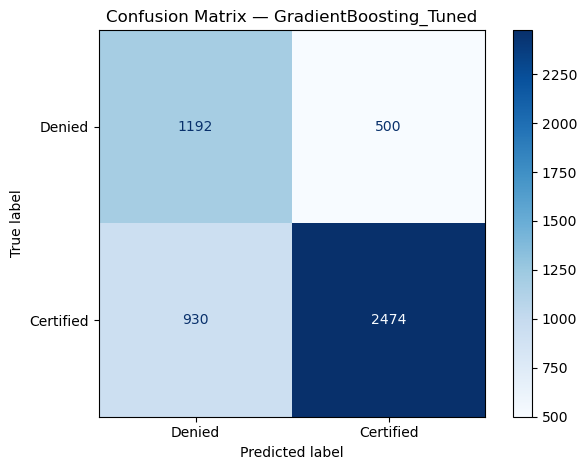

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
30,GradientBoosting_Tuned,Undersampled,Train,0.7149,0.7226,0.7099,0.7175,0.7357,0.7940,3551,1527,1342,3736
31,GradientBoosting_Tuned,Undersampled,Validation,0.8085,0.7758,0.8319,0.7194,0.7268,0.7875,1192,500,930,2474


In [170]:
tuned_train = evaluate_model("GradientBoosting_Tuned", gbc_tuned, X_train_under, y_train_under, plot_cm=False, verbose=False)
tuned_train['Data'] = 'Undersampled'
tuned_train['Set'] = 'Train'

tuned_val = evaluate_model("GradientBoosting_Tuned", gbc_tuned, X_val, y_val, plot_cm=True, verbose=True)
tuned_val['Data'] = 'Undersampled'
tuned_val['Set'] = 'Validation'

all_results += [tuned_train, tuned_val]
results_df = build_results_df(all_results)
results_df[results_df['Model'].str.contains('Tuned')]

**GradientBoosting Undersampled, Tuned Observations**

- Hyperparameter tuning yielded negligible improvement over default parameters (F0.5: 0.8082 untuned → 0.8085 tuned at n_iter=100), suggesting model was already near performance ceiling.
- Results were stable across n_iter = 20 and n_iter = 100 indicating search converged reliably.

## Bagging Original Data Hyperparameter Tuning

In [171]:
%%time
# Bagging - Original Data - Hyperparameter Tuning via RandomizedSearchCV
param_distributions = {
    "estimator": [DecisionTreeClassifier(max_depth=d, random_state=1) for d in [3, 5, 7, 10, None]],
    "n_estimators": randint(20, 150),
    "max_samples": uniform(0.5, 0.5),    # samples continuously in [0.5, 1.0)
    "max_features": uniform(0.5, 0.5),   # samples continuously in [0.5, 1.0)
}

bagging_search = RandomizedSearchCV(
    estimator=BaggingClassifier(random_state=1),
    param_distributions=param_distributions,
    n_iter=100,
    scoring=f05_scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

bagging_search.fit(X_train, y_train)

bagging_tuned = bagging_search.best_estimator_
print("Best Parameters:", bagging_search.best_params_)
print("Best CV F0.5 Score:", bagging_search.best_score_)

Best Parameters: {'estimator': DecisionTreeClassifier(max_depth=7, random_state=1), 'max_features': np.float64(0.9868917691791612), 'max_samples': np.float64(0.8023580504870265), 'n_estimators': 66}
Best CV F0.5 Score: 0.7967548270677638
CPU times: total: 6.16 s
Wall time: 44.8 s


  Model: Bagging_Tuned
  Accuracy         0.7514
  Recall           0.8672
  Precision        0.7836
  F1 Score         0.8233
  F0.5 Score       0.7990
  ROC-AUC          0.7897


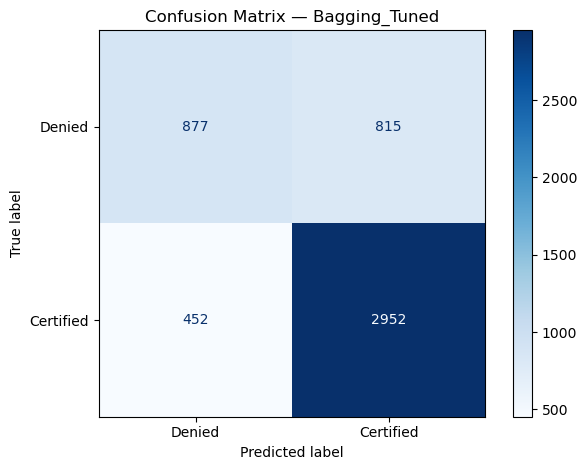

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
30,GradientBoosting_Tuned,Undersampled,Train,0.7149,0.7226,0.7099,0.7175,0.7357,0.7940,3551,1527,1342,3736
31,GradientBoosting_Tuned,Undersampled,Validation,0.8085,0.7758,0.8319,0.7194,0.7268,0.7875,1192,500,930,2474
32,Bagging_Tuned,Original,Train,0.8037,0.8306,0.7867,0.7603,0.8797,0.8075,2642,2436,1228,8982
33,Bagging_Tuned,Original,Validation,0.7990,0.8233,0.7836,0.7514,0.8672,0.7897,877,815,452,2952


In [172]:
tuned_train = evaluate_model("Bagging_Tuned", bagging_tuned, X_train, y_train, plot_cm=False, verbose=False)
tuned_train['Data'] = 'Original'
tuned_train['Set'] = 'Train'

tuned_val = evaluate_model("Bagging_Tuned", bagging_tuned, X_val, y_val, plot_cm=True, verbose=True)
tuned_val['Data'] = 'Original'
tuned_val['Set'] = 'Validation'

all_results += [tuned_train, tuned_val]
results_df = build_results_df(all_results)
results_df[results_df['Model'].str.contains('Tuned')]

**Bagging Original Data, Tuned Observations**

- +0.0295 improvement in F0.5 score over the untuned model with notable improvement in recall and precision.
- Beats the GradientBoosting_Tuned, Undersampled model in recall, but loses on precision and the F0.5 score.

## Random Forest Original Data Hyperparameter Tuning

In [173]:
%%time
# Random Forest - Original Data - Hyperparameter Tuning via RandomizedSearchCV
param_distributions = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(3, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": uniform(0.3, 0.6),   # samples continuously in [0.3, 0.9)
    "max_samples": uniform(0.4, 0.5),    # samples continuously in [0.4, 0.9)
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1, class_weight='balanced'),
    param_distributions=param_distributions,
    n_iter=100,
    scoring=f05_scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_tuned = rf_search.best_estimator_
print("Best Parameters:", rf_search.best_params_)
print("Best CV F0.5 Score:", rf_search.best_score_)

Best Parameters: {'max_depth': 9, 'max_features': np.float64(0.3238101012394358), 'max_samples': np.float64(0.8069381825861688), 'min_samples_leaf': 2, 'n_estimators': 137}
Best CV F0.5 Score: 0.8069992038778075
CPU times: total: 5.02 s
Wall time: 56.5 s


  Model: RandomForest_Tuned
  Accuracy         0.7268
  Recall           0.7585
  Precision        0.8192
  F1 Score         0.7877
  F0.5 Score       0.8063
  ROC-AUC          0.7928


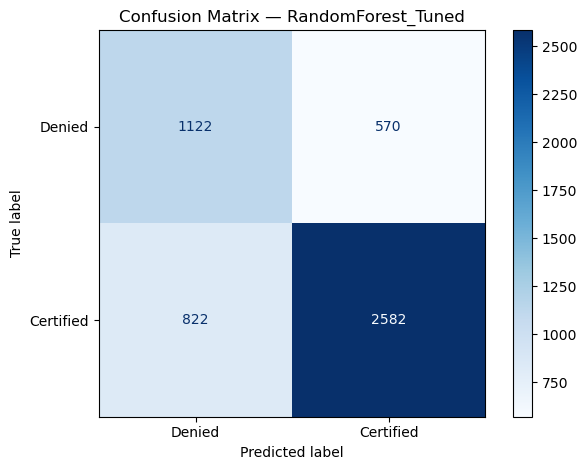

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
30,GradientBoosting_Tuned,Undersampled,Train,0.7149,0.7226,0.7099,0.7175,0.7357,0.7940,3551,1527,1342,3736
31,GradientBoosting_Tuned,Undersampled,Validation,0.8085,0.7758,0.8319,0.7194,0.7268,0.7875,1192,500,930,2474
32,Bagging_Tuned,Original,Train,0.8037,0.8306,0.7867,0.7603,0.8797,0.8075,2642,2436,1228,8982
33,Bagging_Tuned,Original,Validation,0.7990,0.8233,0.7836,0.7514,0.8672,0.7897,877,815,452,2952
34,RandomForest_Tuned,Original,Train,0.8262,0.8111,0.8366,0.7551,0.7871,0.8278,3508,1570,2174,8036
35,RandomForest_Tuned,Original,Validation,0.8063,0.7877,0.8192,0.7268,0.7585,0.7928,1122,570,822,2582


In [174]:
tuned_train = evaluate_model("RandomForest_Tuned", rf_tuned, X_train, y_train, plot_cm=False, verbose=False)
tuned_train['Data'] = 'Original'
tuned_train['Set'] = 'Train'

tuned_val = evaluate_model("RandomForest_Tuned", rf_tuned, X_val, y_val, plot_cm=True, verbose=True)
tuned_val['Data'] = 'Original'
tuned_val['Set'] = 'Validation'

all_results += [tuned_train, tuned_val]
results_df = build_results_df(all_results)
results_df[results_df['Model'].str.contains('Tuned')]

**Random Forest Original Data, Tuned Observations**

- +0.0253 improvement in F0.5 score over the untuned model.  
- Overfitting resolved.

## AdaBoost Undersampled Hyperparameter Tuning

In [175]:
%%time
# AdaBoost - Undersampled - Hyperparameter Tuning via RandomizedSearchCV
param_distributions = {
    "estimator": [DecisionTreeClassifier(max_depth=d, random_state=1) for d in [1, 2, 3, 4]],
    "n_estimators": randint(50, 250),
    "learning_rate": uniform(0.01, 0.99),   # samples continuously in [0.01, 1.0)
}

ada_search = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=1),
    param_distributions=param_distributions,
    n_iter=100,
    scoring=f05_scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

ada_search.fit(X_train_under, y_train_under)

ada_tuned = ada_search.best_estimator_
print("Best Parameters:", ada_search.best_params_)
print("Best CV F0.5 Score:", ada_search.best_score_)

Best Parameters: {'estimator': DecisionTreeClassifier(max_depth=4, random_state=1), 'learning_rate': np.float64(0.2437280871824563), 'n_estimators': 179}
Best CV F0.5 Score: 0.7035688281853176
CPU times: total: 6 s
Wall time: 50.6 s


  Model: AdaBoost_Tuned
  Accuracy         0.7172
  Recall           0.7186
  Precision        0.8351
  F1 Score         0.7725
  F0.5 Score       0.8089
  ROC-AUC          0.7899


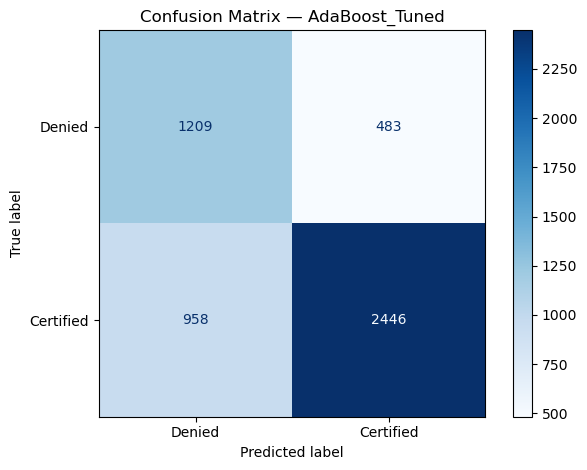

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
30,GradientBoosting_Tuned,Undersampled,Train,0.7149,0.7226,0.7099,0.7175,0.7357,0.7940,3551,1527,1342,3736
31,GradientBoosting_Tuned,Undersampled,Validation,0.8085,0.7758,0.8319,0.7194,0.7268,0.7875,1192,500,930,2474
32,Bagging_Tuned,Original,Train,0.8037,0.8306,0.7867,0.7603,0.8797,0.8075,2642,2436,1228,8982
33,Bagging_Tuned,Original,Validation,0.7990,0.8233,0.7836,0.7514,0.8672,0.7897,877,815,452,2952
34,RandomForest_Tuned,Original,Train,0.8262,0.8111,0.8366,0.7551,0.7871,0.8278,3508,1570,2174,8036
35,RandomForest_Tuned,Original,Validation,0.8063,0.7877,0.8192,0.7268,0.7585,0.7928,1122,570,822,2582
36,AdaBoost_Tuned,Undersampled,Train,0.7109,0.7167,0.7070,0.7128,0.7267,0.7926,3549,1529,1388,3690
37,AdaBoost_Tuned,Undersampled,Validation,0.8089,0.7725,0.8351,0.7172,0.7186,0.7899,1209,483,958,2446


In [176]:
tuned_train = evaluate_model("AdaBoost_Tuned", ada_tuned, X_train_under, y_train_under, plot_cm=False, verbose=False)
tuned_train['Data'] = 'Undersampled'
tuned_train['Set'] = 'Train'

tuned_val = evaluate_model("AdaBoost_Tuned", ada_tuned, X_val, y_val, plot_cm=True, verbose=True)
tuned_val['Data'] = 'Undersampled'
tuned_val['Set'] = 'Validation'

all_results += [tuned_train, tuned_val]
results_df = build_results_df(all_results)
results_df[results_df['Model'].str.contains('Tuned')]

**AdaBoost Undersampled, Tuned Observations**

- +0.0094 improvement in F0.5 score over the untuned model.
- Top performing F0.5 score to this point.

## XGBoost Oversampled Hyperparameter Tuning

In [177]:
%%time
# XGBoost - Oversampled - Hyperparameter Tuning via RandomizedSearchCV
param_distributions = {
    "n_estimators": randint(50, 250),
    "max_depth": randint(2, 10),
    "learning_rate": uniform(0.01, 0.29),      # samples continuously in [0.01, 0.30)
    "subsample": uniform(0.6, 0.4),            # samples continuously in [0.6, 1.0)
    "colsample_bytree": uniform(0.5, 0.5),     # samples continuously in [0.5, 1.0)
    "gamma": uniform(0, 5),
    "scale_pos_weight": [1, 2, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=1, eval_metric='logloss'),
    param_distributions=param_distributions,
    n_iter=100,
    scoring=f05_scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

xgb_search.fit(X_train_over, y_train_over)

xgb_tuned = xgb_search.best_estimator_
print("Best Parameters:", xgb_search.best_params_)
print("Best CV F0.5 Score:", xgb_search.best_score_)

Best Parameters: {'colsample_bytree': np.float64(0.7868397433361429), 'gamma': np.float64(0.01435163515579485), 'learning_rate': np.float64(0.18897202495000992), 'max_depth': 6, 'n_estimators': 168, 'scale_pos_weight': 1, 'subsample': np.float64(0.6036031987844171)}
Best CV F0.5 Score: 0.7659903659986599
CPU times: total: 9.5 s
Wall time: 14.1 s


  Model: XGBoost_Tuned
  Accuracy         0.7210
  Recall           0.7847
  Precision        0.7949
  F1 Score         0.7898
  F0.5 Score       0.7929
  ROC-AUC          0.7610


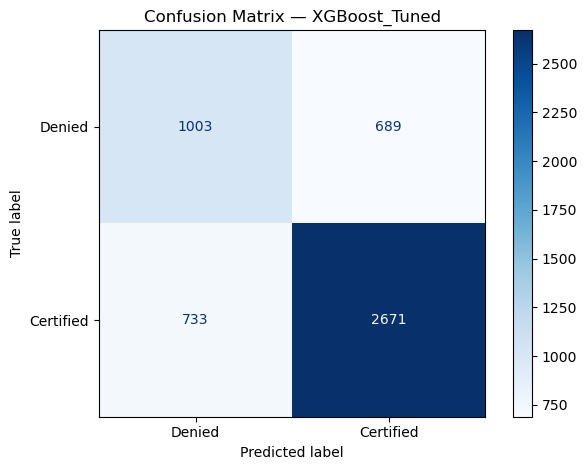

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
30,GradientBoosting_Tuned,Undersampled,Train,0.7149,0.7226,0.7099,0.7175,0.7357,0.7940,3551,1527,1342,3736
31,GradientBoosting_Tuned,Undersampled,Validation,0.8085,0.7758,0.8319,0.7194,0.7268,0.7875,1192,500,930,2474
32,Bagging_Tuned,Original,Train,0.8037,0.8306,0.7867,0.7603,0.8797,0.8075,2642,2436,1228,8982
33,Bagging_Tuned,Original,Validation,0.7990,0.8233,0.7836,0.7514,0.8672,0.7897,877,815,452,2952
34,RandomForest_Tuned,Original,Train,0.8262,0.8111,0.8366,0.7551,0.7871,0.8278,3508,1570,2174,8036
35,RandomForest_Tuned,Original,Validation,0.8063,0.7877,0.8192,0.7268,0.7585,0.7928,1122,570,822,2582
36,AdaBoost_Tuned,Undersampled,Train,0.7109,0.7167,0.7070,0.7128,0.7267,0.7926,3549,1529,1388,3690
37,AdaBoost_Tuned,Undersampled,Validation,0.8089,0.7725,0.8351,0.7172,0.7186,0.7899,1209,483,958,2446
38,XGBoost_Tuned,Oversampled,Train,0.8522,0.8581,0.8482,0.8565,0.8683,0.9377,8624,1586,1345,8865
39,XGBoost_Tuned,Oversampled,Validation,0.7929,0.7898,0.7949,0.7210,0.7847,0.7610,1003,689,733,2671


In [178]:
tuned_train = evaluate_model("XGBoost_Tuned", xgb_tuned, X_train_over, y_train_over, plot_cm=False, verbose=False)
tuned_train['Data'] = 'Oversampled'
tuned_train['Set'] = 'Train'

tuned_val = evaluate_model("XGBoost_Tuned", xgb_tuned, X_val, y_val, plot_cm=True, verbose=True)
tuned_val['Data'] = 'Oversampled'
tuned_val['Set'] = 'Validation'

all_results += [tuned_train, tuned_val]
results_df = build_results_df(all_results)
results_df[results_df['Model'].str.contains('Tuned')]

**XGBoost Oversampled, Tuned Observations**

- Slight degradation of F0.5 score (-.0011)
- Overfitting not resolved

# **Model Comparison and Final Model Selection**

In [179]:
#Compare all models on training data
results_df[results_df['Set'] == 'Train'].sort_values('F0.5 Score', ascending=False)

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
2,Random Forest,Original,Train,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5078,0,0,10210
22,Random Forest,Undersampled,Train,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5078,0,0,5078
12,Random Forest,Oversampled,Train,0.9999,1.0000,0.9999,1.0000,1.0000,1.0000,10209,1,0,10210
10,Bagging,Oversampled,Train,0.9806,0.9850,0.9777,0.9849,0.9924,0.9989,9979,231,78,10132
0,Bagging,Original,Train,0.9774,0.9847,0.9726,0.9793,0.9972,0.9987,4791,287,29,10181
20,Bagging,Undersampled,Train,0.9741,0.9803,0.9699,0.9801,0.9909,0.9985,4922,156,46,5032
8,XGBoost,Original,Train,0.8737,0.8985,0.8580,0.8577,0.9430,0.9284,3484,1594,582,9628
28,XGBoost,Undersampled,Train,0.8713,0.8761,0.8681,0.8750,0.8842,0.9505,4396,682,588,4490
18,XGBoost,Oversampled,Train,0.8602,0.8679,0.8552,0.8659,0.8810,0.9445,8687,1523,1215,8995
38,XGBoost_Tuned,Oversampled,Train,0.8522,0.8581,0.8482,0.8565,0.8683,0.9377,8624,1586,1345,8865


In [180]:
#Compare all models on validation data
results_df[results_df['Set'] == 'Validation'].sort_values('F0.5 Score', ascending=False)

,Model,Data,Set,F0.5 Score,F1 Score,Precision,Accuracy,Recall,ROC-AUC,TN,FP,FN,TP
37,AdaBoost_Tuned,Undersampled,Validation,0.8089,0.7725,0.8351,0.7172,0.7186,0.7899,1209,483,958,2446
31,GradientBoosting_Tuned,Undersampled,Validation,0.8085,0.7758,0.8319,0.7194,0.7268,0.7875,1192,500,930,2474
27,GradientBoosting,Undersampled,Validation,0.8082,0.7766,0.8307,0.7198,0.7291,0.7891,1186,506,922,2482
35,RandomForest_Tuned,Original,Validation,0.8063,0.7877,0.8192,0.7268,0.7585,0.7928,1122,570,822,2582
17,GradientBoosting,Oversampled,Validation,0.8033,0.7693,0.8277,0.7121,0.7186,0.7840,1183,509,958,2446
7,GradientBoosting,Original,Validation,0.8009,0.8266,0.7846,0.7553,0.8734,0.7910,876,816,431,2973
25,AdaBoost,Undersampled,Validation,0.7995,0.7660,0.8236,0.7078,0.7159,0.7762,1170,522,967,2437
33,Bagging_Tuned,Original,Validation,0.7990,0.8233,0.7836,0.7514,0.8672,0.7897,877,815,452,2952
15,AdaBoost,Oversampled,Validation,0.7983,0.7667,0.8209,0.7076,0.7192,0.7730,1158,534,956,2448
19,XGBoost,Oversampled,Validation,0.7940,0.7934,0.7944,0.7243,0.7923,0.7696,994,698,707,2697


Note: for models trained on Oversampled or Undersampled data, "Train" metrics reflect performance against an artificially balanced label distribution, not the natural 67/33 split used for Validation. As a result, train-validation gaps for Oversampled/Undersampled variants aren't a pure apples-to-apples generalization measure the way they are for Original-data models — Validation remains the consistent basis for all model comparisons and selection.

**Comparison Observations**
- By our chosen metric of F0.5 score, AdaBoost_tuned with undersampled data was the best performing model on the validation set (F0.5 = 0.8089).
- Worth noting that if we chose to grade on F1 score, the winner would be GradientBoosting on the original data.  This could be offered to the client as an alternate option if they wish to equally weight precision and recall.

  Model: AdaBoost_Tuned_FINAL
  Accuracy         0.7062
  Recall           0.7256
  Precision        0.8144
  F1 Score         0.7674
  F0.5 Score       0.7949
  ROC-AUC          0.7658


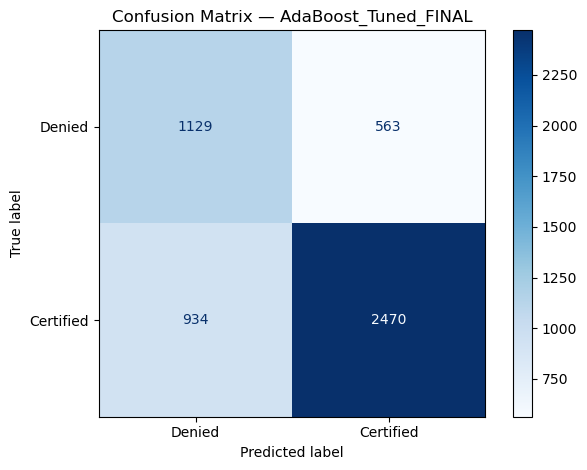

In [181]:
# Final Model Evaluation on Test Set
# AdaBoost_Tuned (Undersampled) was selected based on validation performance
test_result = evaluate_model("AdaBoost_Tuned_FINAL", ada_tuned, X_test, y_test, plot_cm=True, verbose=True)

In [182]:
print(f"True Negatives (correctly Denied): {test_result['TN']}")
print(f"False Positives (wrongly Certified): {test_result['FP']}")
print(f"False Negatives (wrongly Denied): {test_result['FN']}")
print(f"True Positives (correctly Certified): {test_result['TP']}")

True Negatives (correctly Denied): 1129
False Positives (wrongly Certified): 563
False Negatives (wrongly Denied): 934
True Positives (correctly Certified): 2470


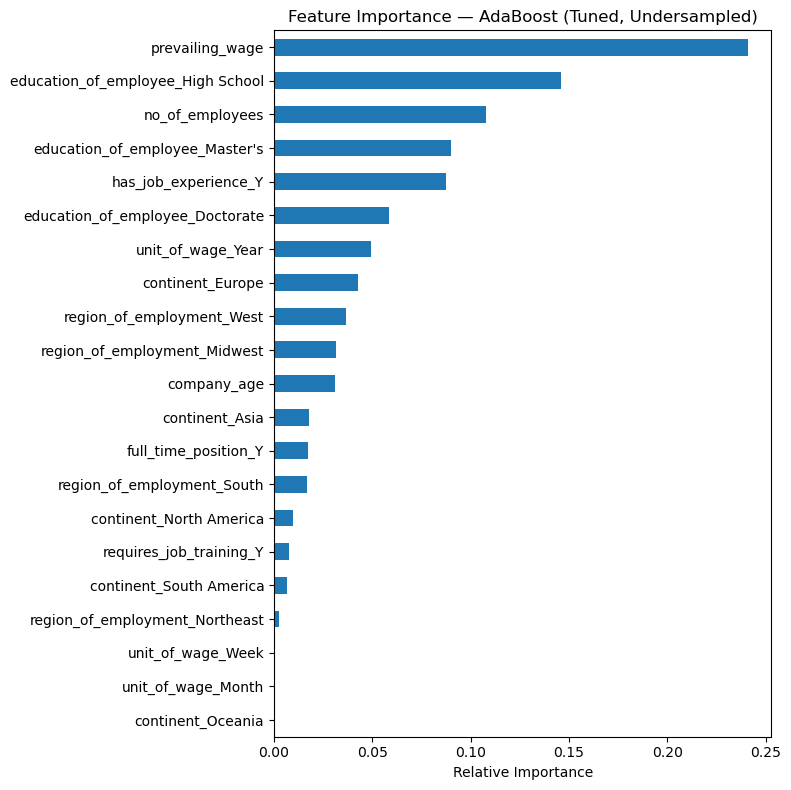

In [183]:
# Feature Importance — Final Model (AdaBoost_Tuned)
importances = pd.Series(ada_tuned.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)  # ascending so barh plots largest on top

plt.figure(figsize=(8, 8))
importances.plot(kind='barh')
plt.xlabel('Relative Importance')
plt.title('Feature Importance — AdaBoost (Tuned, Undersampled)')
plt.tight_layout()
plt.show()

**Final Model Observations**
- Our final model has a F0.5 score of .7949.
- As expected when grading on F0.5 score, we see more False Negatives (934) than False Positives (563)
- The top 3 important features in prediction for the model were: prevailing wage, highschool education, and number of employees.

# **Actionable Insights and Recommendations**

## Insights

- Overall 66.8% of applications were approved and certified.
    - Doctorate's have the highest approval rate at 87.2% while High School Education has the lowest at 34.0%
    - Europe has the highest proportion of applications approved (79.2%) while South America has the lowest (57.9%)
    - There is a 74.5% approval rate for those with job experience vs a 56.1% approval rate for those without
    - Midwest region has the highest percent of cases approved (75.5%) while Island region has the lowest percent approved (60.3%) (small sample size at only .8% of data - interpret cautiously)
    - Roles with a yearly wage were Certified at the highest rate (69.9%) while hourly roles had the lowest certification rate (34.6%)
- The top 3 important features in prediction for the selected model were: prevailing wage, highschool education, and number of employees.

## Recommendations

1. Implement our selected AdaBoost_tuned model
    - Best performing model on the validation set (F0.5 = 0.8089)
    - Test F0.5 score of .7949
2. Consider GradientBoosting model as alternative if client desires equal weight between precision and recall (ie balanced false positive and false negative rates).
    - Top performing F1 score of .8266 on validation set
3. Validate data and consider running same process on a fresh set if available.  Indicators of potentially bad data:
    - 6.9% of dataset represents yearly wage roles paid under the national minimum wage
    - A significant amount of Monthly and Weekly wages are unrealistically high (ie 50% of Monthly wages > `$76,174` per month; 50% of weekly wages > `$85,075` per week.
    - Yearly wages are associated with the highest percent of part time roles at 11.6% of yearly wages associated with roles that are not full time
    - Overall, prevailing_wage does not appear to scale meaningfully with unit_of_wage, making any attempt cross-unit normalization practically meaningless.


___